# Deep Condition Retrieval Analysis — Impressions Dataset

Systematic investigation of the following open questions:

1. **Mean vs Max aggregation** — what does each strategy do per caption type? When does mean hurt?
2. **Single "correct" condition** — if we pick the oracle representative per query, how much do we gain vs per-type-oracle vs predictor?
3. **Stable condition finding** — can the caption type stably predict which representative is correct?
4. **Condition manifold w.r.t. GTs** — do training conditions cluster by caption type?
5. **Per-condition effectiveness** — which representatives help which types, and by how much?

**Requires**: `condition_viz/` and `condition_analysis/` caches from the training run.
Run `train_cosir.py` to generate `condition_analysis/epoch_*.pt`.

In [1]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT_DIR = (
    "/project/CoSiR/res/CoSiR_Experiment/impressions/20260513_115149_CoSiR_Experiment"
)
TRAIN_JSON_PATH = "/project/Impressions/metadata/impressions_train.json"
EPOCH = None        # None → latest available epoch snapshot
DEVICE = "cuda"    # set to "cpu" if no GPU
N_EXAMPLES = 5     # number of qualitative examples to show

TYPE_NAMES = ["caption", "description", "impression", "aesthetic"]
TYPE_COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os, sys, glob, json, warnings
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import defaultdict

warnings.filterwarnings("ignore")

# Import model files directly to avoid triggering src/model/__init__.py (which loads cuml)
import importlib.util as _ilu
def _load_file(name, path):
    spec = _ilu.spec_from_file_location(name, path)
    mod = _ilu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

_proj = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), "../../.."))
Combiner_new = _load_file("combiner", os.path.join(_proj, "src/model/combiner.py")).Combiner_new
ConditionPredictor = _load_file("condition_predictor", os.path.join(_proj, "src/model/condition_predictor.py")).ConditionPredictor

cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")
ca_dir   = os.path.join(EXPERIMENT_DIR, "condition_analysis")

# ── Fixed test data ───────────────────────────────────────────────────────────
fixed = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu", weights_only=False)
all_img_emb   = fixed["all_img_emb"]          # [N_img, D]
all_txt_emb   = fixed["all_txt_emb"]          # [N_txt, D]
all_raw_text  = fixed["all_raw_text"]
image_paths   = fixed["image_paths"]
img2txt       = fixed["image_to_text_map"]   # [N_img, cpi]
txt2img       = fixed["text_to_image_map"]   # [N_txt]
cpi           = fixed["captions_per_image"]
test_cap_types = fixed.get("test_caption_types")  # [N_txt]
n_img, n_txt  = all_img_emb.shape[0], all_txt_emb.shape[0]
print(f"Test set: {n_img} images × {cpi} caps = {n_txt} texts")

# Reconstruct test_caption_types from annotation file if missing
if test_cap_types is None:
    _tpath = os.path.join(os.path.dirname(TRAIN_JSON_PATH), "impressions_test.json")
    _tm = {"caption": 0, "description": 1, "impression": 2, "aesthetic": 3}
    test_cap_types = torch.tensor(
        [_tm[t] for ann in json.load(open(_tpath)) for t in ann["caption_type"]],
        dtype=torch.long,
    )
    print(f"  Reconstructed test_caption_types from JSON")

# ── Epoch snapshot ────────────────────────────────────────────────────────────
epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap_path   = epoch_files[-1] if EPOCH is None else os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt")
snap        = torch.load(snap_path, map_location="cpu", weights_only=False)
epoch       = snap["epoch"]
label_emb_all  = snap["label_embeddings_all"]  # [N_train, D_cond]
representatives = snap["representatives"]       # [K, D_cond]
combine_side    = snap.get("combine_side", "img")
train_types     = snap.get("train_sample_types")  # [N_train] or None
K        = len(representatives)
label_dim = representatives.shape[1]
print(f"Epoch {epoch}: K={K} representatives, label_dim={label_dim}, combine_side={combine_side}")

# ── Condition analysis cache ──────────────────────────────────────────────────
ca_files = sorted(glob.glob(os.path.join(ca_dir, "epoch_*.pt"))) if os.path.exists(ca_dir) else []
HAS_CA = False
if ca_files:
    ca_path = ca_files[-1] if EPOCH is None else os.path.join(ca_dir, f"epoch_{EPOCH:04d}.pt")
    if not os.path.exists(ca_path): ca_path = ca_files[-1]
    ca = torch.load(ca_path, map_location="cpu", weights_only=False)
    per_rep_gt_rank    = ca["per_rep_gt_rank"]         # [K, N_txt]
    oracle_cond_idx    = ca["oracle_condition_idx"]    # [N_txt]
    mean_topk_idx      = ca["mean_topk_indices"]       # [N_txt, top_k]
    max_topk_idx       = ca["max_topk_indices"]        # [N_txt, top_k]
    per_rep_topk_idx   = ca["per_rep_topk_indices"]    # [K, N_txt, top_k]
    per_rep_topk_scores = ca["per_rep_topk_scores"]   # [K, N_txt, top_k]
    clip_gt_rank_ca    = ca.get("clip_gt_rank")        # [N_txt]
    HAS_CA = True
    print(f"Loaded condition analysis cache (epoch {ca['epoch']})")
else:
    print("WARNING: No condition_analysis cache found. Rebuild model to compute on-the-fly.")

# ── CLIP baseline ranks (always computable) ───────────────────────────────────
img_n = F.normalize(all_img_emb, dim=-1)
txt_n = F.normalize(all_txt_emb, dim=-1)
clip_sims     = txt_n @ img_n.T                             # [N_txt, N_img]
clip_gt_sims  = clip_sims[torch.arange(n_txt), txt2img]
clip_gt_rank  = (clip_sims >= clip_gt_sims.unsqueeze(1)).sum(dim=1).long() - 1  # [N_txt]
clip_r1  = (clip_gt_rank == 0).float().mean().item() * 100
clip_r5  = (clip_gt_rank < 5).float().mean().item() * 100
clip_r10 = (clip_gt_rank < 10).float().mean().item() * 100
print(f"\nCLIP baseline T2I: R@1={clip_r1:.1f}  R@5={clip_r5:.1f}  R@10={clip_r10:.1f}")

Test set: 706 images × 4 caps = 2824 texts
Epoch 999: K=30 representatives, label_dim=16, combine_side=img
Loaded condition analysis cache (epoch 999)

CLIP baseline T2I: R@1=47.8  R@5=73.4  R@10=81.4


---
## 0 — Rebuild Combiner & Condition Predictor

Needed for any cells that require model inference (type-mean conditions, predictor, etc.).

In [3]:
dev = torch.device(DEVICE if torch.cuda.is_available() else "cpu")

combiner_cfg = snap["combiner_config"]
combiner = Combiner_new(
    clip_feature_dim=combiner_cfg["clip_feature_dim"],
    projection_dim=combiner_cfg["projection_dim"],
    label_dim=combiner_cfg["label_dim"],
    hidden_dim=combiner_cfg.get("hidden_dim", combiner_cfg["clip_feature_dim"]),
    num_heads=combiner_cfg.get("num_heads", 8),
    num_layers=combiner_cfg.get("num_layers", 2),
    dropout=combiner_cfg.get("dropout", 0.1),
).to(dev).eval()
combiner.load_state_dict(snap["combiner_state_dict"])
print("Combiner loaded")

predictor = None
if "predictor_state_dict" in snap and "predictor_config" in snap:
    pcfg = snap["predictor_config"]
    predictor = ConditionPredictor(
        input_dim=pcfg["input_dim"],
        hidden_dim=pcfg["hidden_dim"],
        output_dim=pcfg["output_dim"],
        num_layers=pcfg.get("num_layers", 2),
        dropout=pcfg.get("dropout", 0.1),
    ).to(dev).eval()
    predictor.load_state_dict(snap["predictor_state_dict"])
    print("Condition predictor loaded")

@torch.no_grad()
def apply_condition(emb: torch.Tensor, cond: torch.Tensor, bs: int = 512) -> torch.Tensor:
    """Apply a single condition vector to all embeddings in `emb`. Returns normalised output."""
    n = emb.shape[0]
    out = []
    for i in range(0, n, bs):
        e = min(i + bs, n)
        out.append(combiner(emb[i:e].to(dev), None, cond.expand(e - i, -1).to(dev)))
    return F.normalize(torch.cat(out, dim=0), dim=-1).cpu()

def rank_after_condition(cond: torch.Tensor) -> torch.Tensor:
    """T2I GT ranks [N_txt] after applying a single condition to the combine side."""
    if combine_side == "txt":
        combined = apply_condition(all_txt_emb, cond)
        sims = combined @ img_n.T
    else:
        combined = apply_condition(all_img_emb, cond)
        sims = txt_n @ combined.T
    gt_s = sims[torch.arange(n_txt), txt2img]
    return (sims >= gt_s.unsqueeze(1)).sum(dim=1).long() - 1

Combiner loaded
Condition predictor loaded


---
## 1 — Aggregation Analysis: Mean vs Max

**Questions**: Which strategy (mean / max over all K representatives) wins per query? Does it differ by caption type? When does averaging hurt?

In [4]:
if not HAS_CA:
    print("Skipped: no condition_analysis cache. Run train_cosir.py first.")
else:
    TOP_K = mean_topk_idx.shape[1]

    # ── GT ranks under mean / max aggregation ────────────────────────────────
    def topk_to_rank(topk_indices: torch.Tensor) -> torch.Tensor:
        """Given [N_txt, K] top-K indices, return GT rank (0=hit in top-K means rank<K).
        If GT not in top-K we assign rank=K as a lower bound."""
        gt = txt2img.unsqueeze(1)  # [N_txt, 1]
        hit_at = (topk_indices == gt).float()
        first_hit = hit_at.argmax(dim=1)                   # [N_txt]
        is_hit = hit_at.any(dim=1).bool()                   # [N_txt]
        rank = torch.where(is_hit, first_hit, torch.full_like(first_hit, TOP_K))
        return rank

    mean_rank = topk_to_rank(mean_topk_idx)  # [N_txt]
    max_rank  = topk_to_rank(max_topk_idx)   # [N_txt]
    # Per-query oracle rank (best single representative)
    oracle_rank = per_rep_gt_rank.min(dim=0).values  # [N_txt]

    # Recall helper
    def r_at_k(ranks: torch.Tensor, k: int) -> float:
        return (ranks < k).float().mean().item() * 100

    print("T2I Recall (R@1 / R@5 / R@10):")
    print(f"  CLIP baseline : {r_at_k(clip_gt_rank,1):.1f} / {r_at_k(clip_gt_rank,5):.1f} / {r_at_k(clip_gt_rank,10):.1f}")
    print(f"  Mean agg      : {r_at_k(mean_rank,1):.1f} / {r_at_k(mean_rank,5):.1f} / {r_at_k(mean_rank,10):.1f}")
    print(f"  Max agg       : {r_at_k(max_rank,1):.1f} / {r_at_k(max_rank,5):.1f} / {r_at_k(max_rank,10):.1f}")
    print(f"  Per-query oracle: {r_at_k(oracle_rank,1):.1f} / {r_at_k(oracle_rank,5):.1f} / {r_at_k(oracle_rank,10):.1f}")

T2I Recall (R@1 / R@5 / R@10):
  CLIP baseline : 47.8 / 73.4 / 81.4
  Mean agg      : 55.2 / 80.1 / 87.6
  Max agg       : 57.2 / 80.3 / 86.5
  Per-query oracle: 82.6 / 95.4 / 97.7


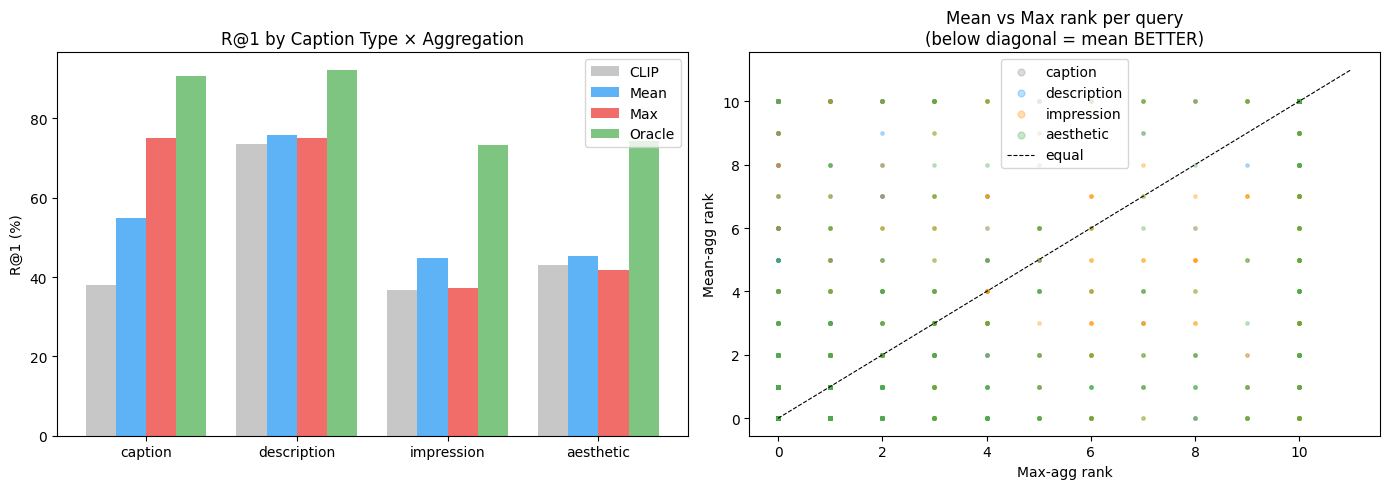


Mean wins over Max: 565 (20.0%)
Max wins over Mean: 567 (20.1%)
Tie:                1692 (59.9%)


In [5]:
if not HAS_CA:
    pass
else:
    # ── 1a: R@1 per caption type for each aggregation strategy ───────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: R@1 per type × strategy
    x = np.arange(4)
    width = 0.2
    ax = axes[0]
    strategies = [
        ("CLIP",   clip_gt_rank, "#bdbdbd"),
        ("Mean",   mean_rank,    "#42a5f5"),
        ("Max",    max_rank,     "#ef5350"),
        ("Oracle", oracle_rank,  "#66bb6a"),
    ]
    for si, (lbl, ranks, col) in enumerate(strategies):
        r1s = [r_at_k(ranks[test_cap_types == t], 1) for t in range(4)]
        ax.bar(x + si * width, r1s, width, label=lbl, color=col, alpha=0.85)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(TYPE_NAMES)
    ax.set_ylabel("R@1 (%)"); ax.set_title("R@1 by Caption Type × Aggregation")
    ax.legend()

    # Scatter: mean-rank vs max-rank, colored by caption type
    ax2 = axes[1]
    for t in range(4):
        mask = test_cap_types == t
        mr = mean_rank[mask].float().numpy()
        xr = max_rank[mask].float().numpy()
        ax2.scatter(xr, mr, s=6, alpha=0.3, color=TYPE_COLORS[t], label=TYPE_NAMES[t])
    lo, hi = 0, TOP_K + 1
    ax2.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="equal")
    ax2.set_xlabel("Max-agg rank"); ax2.set_ylabel("Mean-agg rank")
    ax2.set_title("Mean vs Max rank per query\n(below diagonal = mean BETTER)")
    ax2.legend(markerscale=2)

    plt.tight_layout()
    plt.show()

    # Counts: where does mean win, lose, tie vs max?
    mean_wins  = (mean_rank < max_rank).sum().item()
    max_wins   = (max_rank < mean_rank).sum().item()
    tie        = (mean_rank == max_rank).sum().item()
    print(f"\nMean wins over Max: {mean_wins} ({mean_wins/n_txt*100:.1f}%)")
    print(f"Max wins over Mean: {max_wins} ({max_wins/n_txt*100:.1f}%)")
    print(f"Tie:                {tie} ({tie/n_txt*100:.1f}%)")

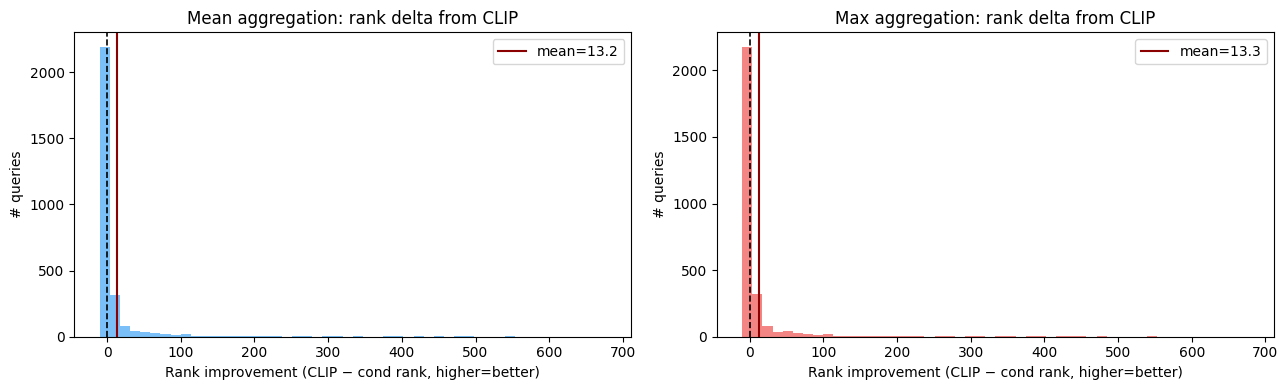


% of queries where rank IMPROVES over CLIP baseline (>0 = conditioning helped):
Type             Mean improves  Max improves
  caption               50.8%          54.0%
  description           19.5%          18.1%
  impression            46.3%          44.3%
  aesthetic             39.1%          38.2%


In [6]:
if not HAS_CA:
    pass
else:
    # ── 1b: Distribution of rank improvement (aggregation vs CLIP) ───────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    clip_r = clip_gt_rank.float()

    for ax, (lbl, ranks, col) in zip(axes, [("Mean", mean_rank.float(), "#42a5f5"),
                                              ("Max",  max_rank.float(),  "#ef5350")]):
        delta = clip_r - ranks  # positive = improvement
        ax.hist(delta.numpy(), bins=50, color=col, alpha=0.7)
        ax.axvline(0, color="k", lw=1.2, ls="--")
        ax.axvline(delta.mean().item(), color="darkred", lw=1.5, label=f"mean={delta.mean():.1f}")
        ax.set_xlabel("Rank improvement (CLIP − cond rank, higher=better)")
        ax.set_ylabel("# queries")
        ax.set_title(f"{lbl} aggregation: rank delta from CLIP")
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Per-type: fraction of queries that IMPROVE vs HURT under each aggregation
    print("\n% of queries where rank IMPROVES over CLIP baseline (>0 = conditioning helped):")
    print(f"{'Type':<15} {'Mean improves':>14} {'Max improves':>13}")
    for t in range(4):
        mask = test_cap_types == t
        d_mean = (clip_r - mean_rank.float())[mask]
        d_max  = (clip_r - max_rank.float())[mask]
        pct_m = (d_mean > 0).float().mean().item() * 100
        pct_x = (d_max > 0).float().mean().item() * 100
        print(f"  {TYPE_NAMES[t]:<13} {pct_m:>12.1f}%  {pct_x:>12.1f}%")

---
## 2 — Per-Condition Effectiveness

**Question**: How does each representative individually affect R@1, and is there a clear winner per caption type?

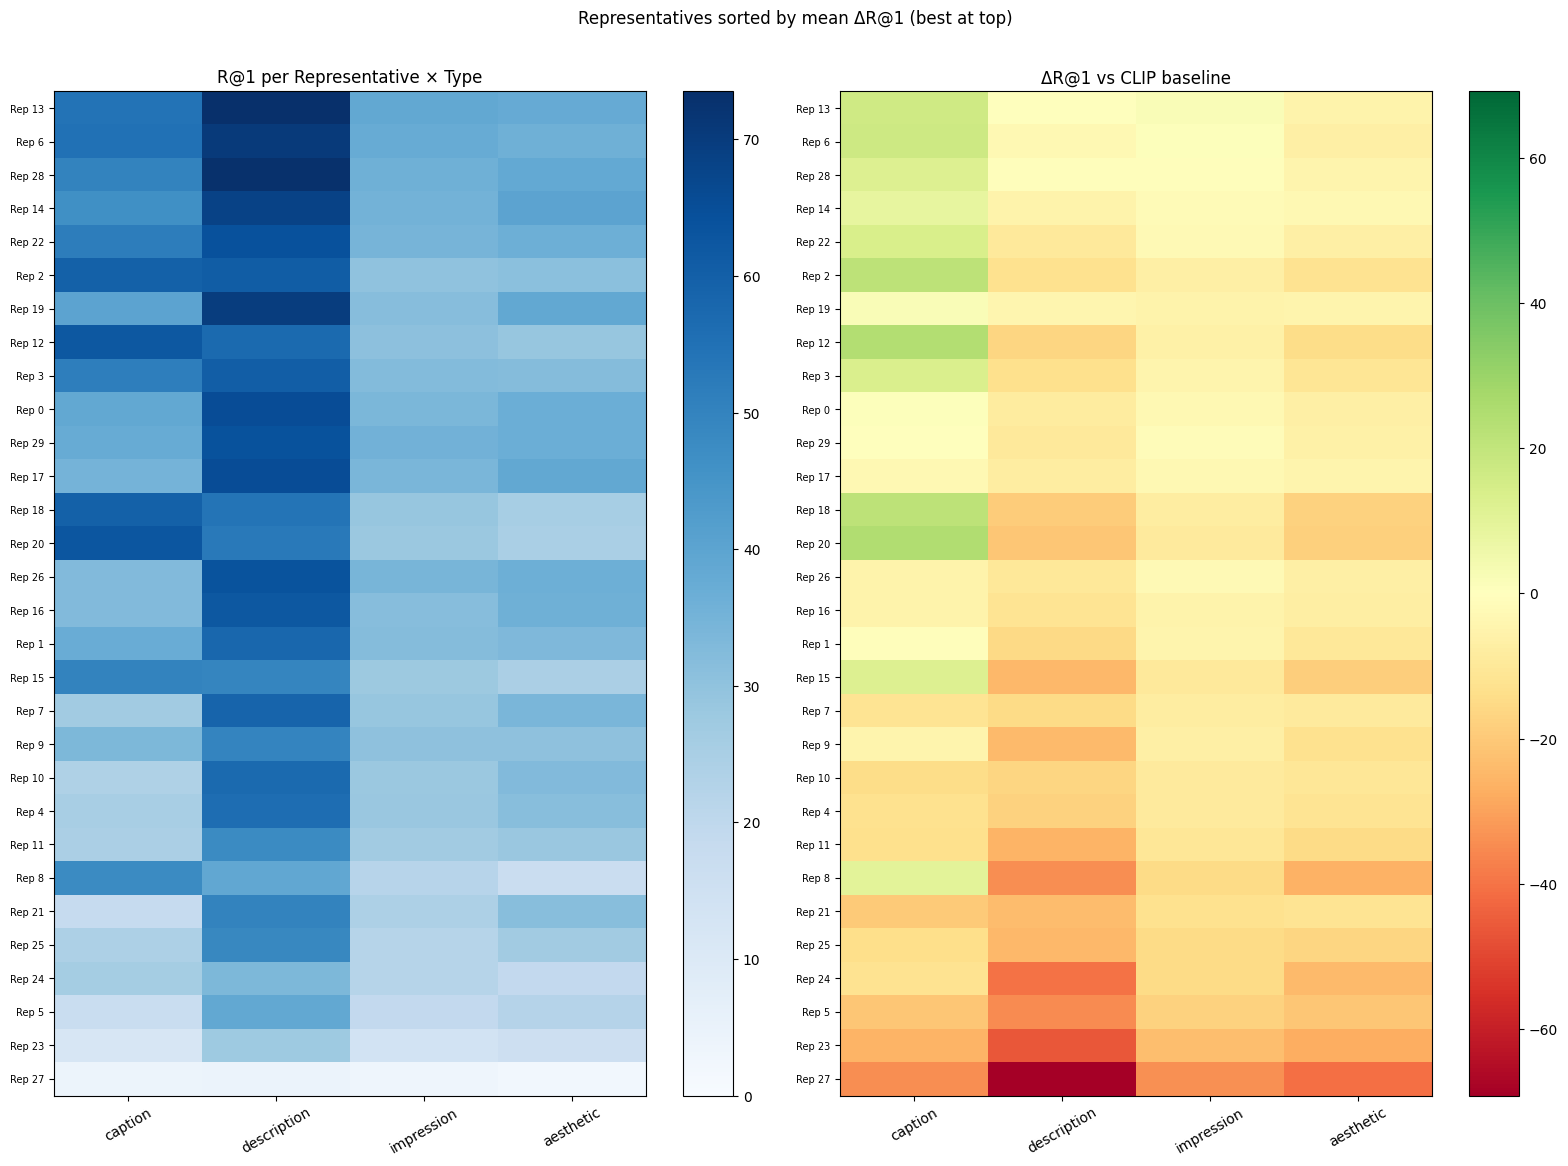


Overall R@1 range: 3.4% — 51.1%
Best  rep (global): #13  R@1=51.1%
Worst rep (global): #27 R@1=3.4%


In [7]:
if not HAS_CA:
    print("Skipped: no CA cache")
else:
    # R@1 for each representative × each caption type
    rep_type_r1 = np.zeros((K, 4))
    rep_r1_all  = np.zeros(K)
    for ri in range(K):
        ranks_ri = per_rep_gt_rank[ri]  # [N_txt]
        rep_r1_all[ri] = r_at_k(ranks_ri, 1)
        for t in range(4):
            mask = test_cap_types == t
            rep_type_r1[ri, t] = r_at_k(ranks_ri[mask], 1)

    # Also compute CLIP baseline per type for delta
    clip_type_r1 = np.array([r_at_k(clip_gt_rank[test_cap_types == t], 1) for t in range(4)])
    rep_type_delta = rep_type_r1 - clip_type_r1[np.newaxis, :]  # [K, 4]

    # Sort reps by mean delta across types
    sort_order = rep_type_delta.mean(axis=1).argsort()[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, K * 0.35 + 1)))

    # Raw R@1 heatmap
    ax = axes[0]
    im = ax.imshow(rep_type_r1[sort_order], aspect="auto", cmap="Blues", vmin=0, vmax=rep_type_r1.max())
    ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, rotation=30)
    ax.set_yticks(range(K)); ax.set_yticklabels([f"Rep {sort_order[i]}" for i in range(K)], fontsize=7)
    ax.set_title("R@1 per Representative × Type")
    plt.colorbar(im, ax=ax)

    # Delta vs CLIP heatmap
    ax2 = axes[1]
    vmax_d = max(abs(rep_type_delta).max(), 1)
    im2 = ax2.imshow(rep_type_delta[sort_order], aspect="auto", cmap="RdYlGn",
                      vmin=-vmax_d, vmax=vmax_d)
    ax2.set_xticks(range(4)); ax2.set_xticklabels(TYPE_NAMES, rotation=30)
    ax2.set_yticks(range(K)); ax2.set_yticklabels([f"Rep {sort_order[i]}" for i in range(K)], fontsize=7)
    ax2.set_title("ΔR@1 vs CLIP baseline")
    plt.colorbar(im2, ax=ax2)

    plt.suptitle("Representatives sorted by mean ΔR@1 (best at top)", y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"\nOverall R@1 range: {rep_r1_all.min():.1f}% — {rep_r1_all.max():.1f}%")
    print(f"Best  rep (global): #{sort_order[0]}  R@1={rep_r1_all[sort_order[0]]:.1f}%")
    print(f"Worst rep (global): #{sort_order[-1]} R@1={rep_r1_all[sort_order[-1]]:.1f}%")

Best representative per caption type (by ΔR@1 over CLIP):
        caption: Rep #20  R@1=62.6%  Δ=+24.6pp
    description: Rep #13  R@1=73.5%  Δ=+0.0pp
     impression: Rep #13  R@1=38.5%  Δ=+1.7pp
      aesthetic: Rep #14  R@1=39.9%  Δ=-3.1pp

Cosine similarity of each representative to caption-type means:


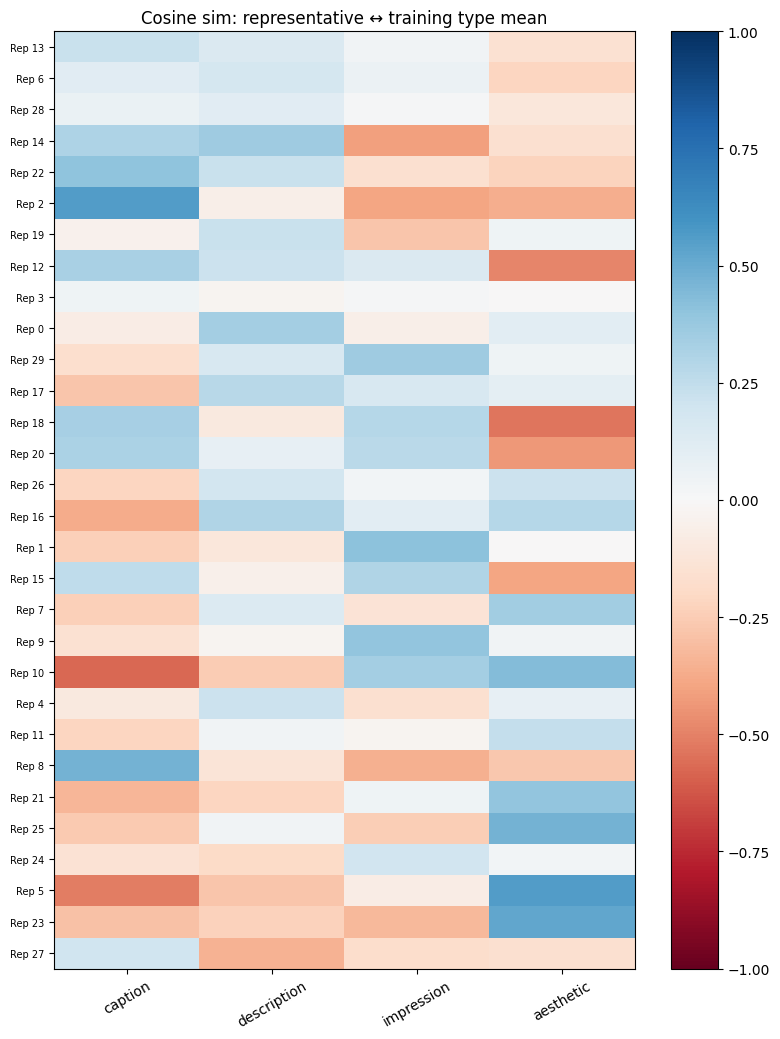

In [8]:
if not HAS_CA:
    pass
else:
    # ── 2b: For each type, which representative is best? ─────────────────────
    print("Best representative per caption type (by ΔR@1 over CLIP):")
    type_best_rep = {}
    for t in range(4):
        best_ri = rep_type_delta[:, t].argmax()
        type_best_rep[t] = int(best_ri)
        print(f"  {TYPE_NAMES[t]:>13}: Rep #{best_ri}  R@1={rep_type_r1[best_ri, t]:.1f}%  "
              f"Δ={rep_type_delta[best_ri, t]:+.1f}pp")

    # Cosine similarity of each rep to training type-mean conditions
    if train_types is not None:
        type_means = torch.stack(
            [label_emb_all[train_types == t].mean(dim=0) for t in range(4)]
        )  # [4, D_cond]
        type_means_n = F.normalize(type_means, dim=-1)
        reps_n = F.normalize(representatives, dim=-1)
        sim_rep_type = (reps_n @ type_means_n.T).numpy()  # [K, 4]

        print("\nCosine similarity of each representative to caption-type means:")
        fig, ax = plt.subplots(figsize=(8, max(3, K * 0.35)))
        im = ax.imshow(sim_rep_type[sort_order], aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
        ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, rotation=30)
        ax.set_yticks(range(K)); ax.set_yticklabels([f"Rep {sort_order[i]}" for i in range(K)], fontsize=7)
        ax.set_title("Cosine sim: representative ↔ training type mean")
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        print("(train_types not available — skipping similarity to type means)")

---
## 3 — The Oracle Hierarchy

Compare multiple levels of oracle knowledge, from strongest to weakest:

| Level | What is known at test time |
|---|---|
| **Full oracle** | GT rank picks best representative *per query* |
| **Type oracle** | Best representative *per caption type* (requires knowing query type) |
| **Type-mean condition** | Mean training embedding per type, applied to matching queries |
| **Condition predictor** | Single forward pass through the predictor network |
| **CLIP baseline** | Raw cosine similarity, no conditioning |

In [9]:
hierarchy_results = {"CLIP": clip_gt_rank}

# Full oracle
if HAS_CA:
    hierarchy_results["Full oracle"] = oracle_rank
    hierarchy_results["Max agg"] = max_rank
    hierarchy_results["Mean agg"] = mean_rank

    # Type oracle: for each caption type, use the best representative uniformly
    type_oracle_ranks = torch.zeros(n_txt, dtype=torch.long)
    for t in range(4):
        mask = (test_cap_types == t)
        best_ri_t = type_best_rep[t]
        type_oracle_ranks[mask] = per_rep_gt_rank[best_ri_t][mask]
    hierarchy_results["Type oracle"] = type_oracle_ranks

# Type-mean condition (requires model)
if train_types is not None:
    type_mean_ranks = torch.zeros(n_txt, dtype=torch.long)
    for t in range(4):
        mask = (test_cap_types == t)
        tm_cond = type_means[t:t+1]
        type_mean_ranks[mask] = rank_after_condition(tm_cond)[mask]
    hierarchy_results["Type-mean cond"] = type_mean_ranks

# Condition predictor
if predictor is not None:
    with torch.no_grad():
        if combine_side == "txt":
            pred_conds_all = []
            for i in range(0, n_txt, 512):
                pred_conds_all.append(predictor(all_txt_emb[i:i+512].to(dev)))
            pred_conds_all = torch.cat(pred_conds_all, dim=0)  # [N_txt, D_cond]
            pred_combined = []
            for i in range(0, n_txt, 512):
                e = min(i + 512, n_txt)
                pred_combined.append(
                    combiner(all_txt_emb[i:e].to(dev), None, pred_conds_all[i:e].to(dev))
                )
            pred_combined = F.normalize(torch.cat(pred_combined, dim=0).cpu(), dim=-1)
            pred_sims = pred_combined @ img_n.T
        else:
            pred_conds_all = []
            for i in range(0, n_img, 512):
                pred_conds_all.append(predictor(all_img_emb[i:i+512].to(dev)))
            pred_conds_all = torch.cat(pred_conds_all, dim=0)  # [N_img, D_cond]
            pred_combined = []
            for i in range(0, n_img, 512):
                e = min(i + 512, n_img)
                pred_combined.append(
                    combiner(all_img_emb[i:e].to(dev), None, pred_conds_all[i:e].to(dev))
                )
            pred_combined = F.normalize(torch.cat(pred_combined, dim=0).cpu(), dim=-1)
            pred_sims = txt_n @ pred_combined.T

    pred_gt_s = pred_sims[torch.arange(n_txt), txt2img]
    pred_gt_rank = (pred_sims >= pred_gt_s.unsqueeze(1)).sum(dim=1).long() - 1
    hierarchy_results["Predictor"] = pred_gt_rank

# Print summary table
print(f"{'Method':<20} {'R@1':>7} {'R@5':>7} {'R@10':>8} {'MedR':>7}")
print("-" * 52)
for name, ranks in sorted(hierarchy_results.items(),
                            key=lambda x: -r_at_k(x[1], 1)):
    medR = ranks.float().median().item()
    print(f"{name:<20} {r_at_k(ranks,1):>7.1f} {r_at_k(ranks,5):>7.1f} "
          f"{r_at_k(ranks,10):>8.1f} {medR:>7.1f}")

Method                   R@1     R@5     R@10    MedR
----------------------------------------------------
Full oracle             82.6    95.4     97.7     0.0
Max agg                 57.2    80.3     86.5     0.0
Mean agg                55.2    80.1     87.6     0.0
Type oracle             53.6    77.2     84.1     0.0
Type-mean cond          51.3    75.2     82.7     0.0
CLIP                    47.8    73.4     81.4     1.0
Predictor               34.3    56.3     65.1     3.0


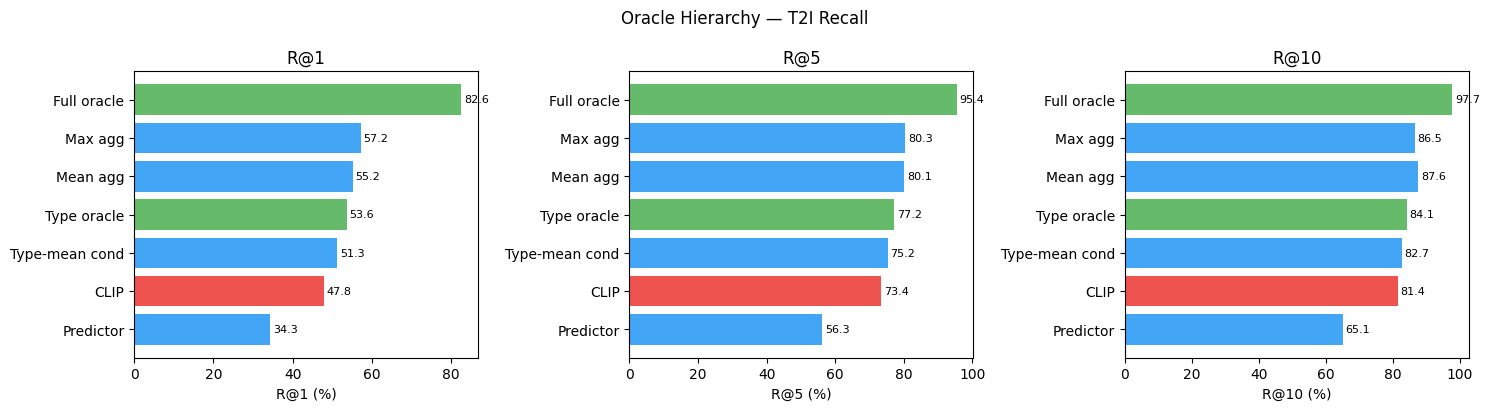

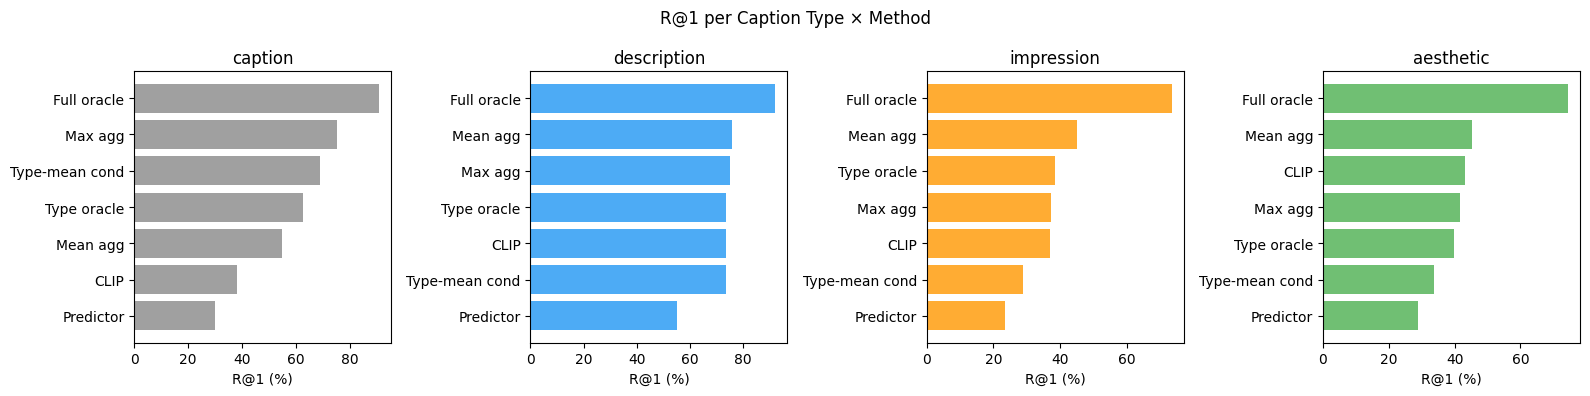

In [10]:
# ── 3a: Hierarchical bar chart ────────────────────────────────────────────────
order = sorted(hierarchy_results.keys(), key=lambda n: r_at_k(hierarchy_results[n], 1))
fig, axes = plt.subplots(1, 3, figsize=(15, max(3, len(order) * 0.45 + 1)))
for ax, k in zip(axes, [1, 5, 10]):
    vals = [r_at_k(hierarchy_results[n], k) for n in order]
    bars = ax.barh(order, vals, color=["#ef5350" if n == "CLIP" else
                                         "#66bb6a" if "oracle" in n.lower() else
                                         "#42a5f5" for n in order])
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
    ax.set_xlabel(f"R@{k} (%)")
    ax.set_title(f"R@{k}")
plt.suptitle("Oracle Hierarchy — T2I Recall")
plt.tight_layout()
plt.show()

# ── 3b: Per-type breakdown for each method ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ti, ax in enumerate(axes):
    mask = test_cap_types == ti
    names_t = list(hierarchy_results.keys())
    vals_t  = [r_at_k(hierarchy_results[n][mask], 1) for n in names_t]
    ord_t   = np.argsort(vals_t)
    ax.barh([names_t[i] for i in ord_t], [vals_t[i] for i in ord_t],
            color=TYPE_COLORS[ti], alpha=0.8)
    ax.set_title(f"{TYPE_NAMES[ti]}")
    ax.set_xlabel("R@1 (%)")
plt.suptitle("R@1 per Caption Type × Method")
plt.tight_layout()
plt.show()

---
## 4 — Stability of Condition Selection

**Question**: For each caption type, does the same representative consistently win, or is the winner query-dependent?

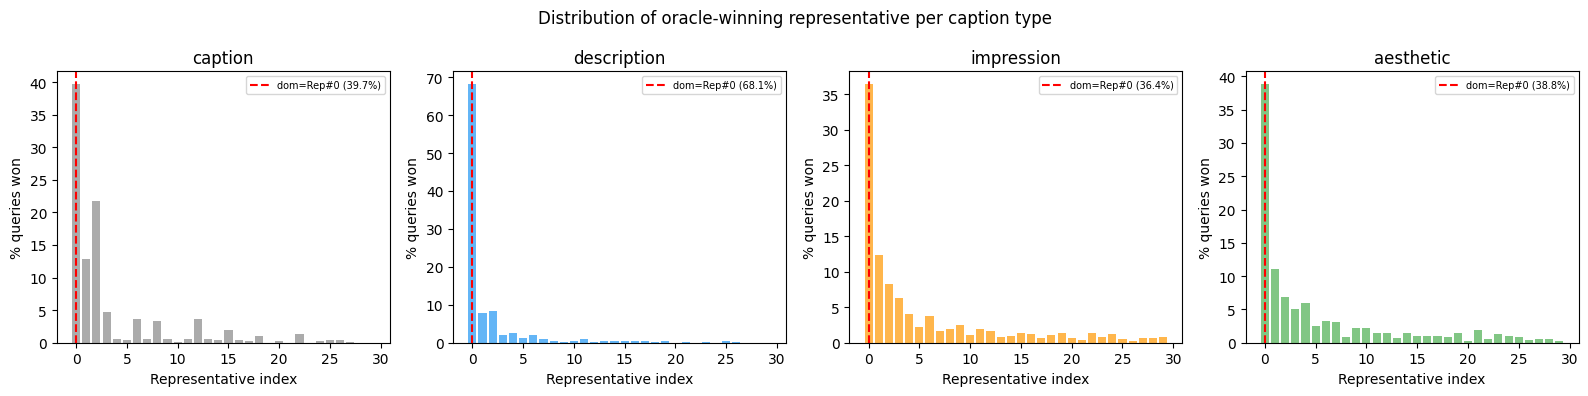


Dominant representative per type (most often oracle-best):
        caption: dominant rep=#0  coverage=39.7%  stability=0.420
    description: dominant rep=#0  coverage=68.1%  stability=0.594
     impression: dominant rep=#0  coverage=36.4%  stability=0.264
      aesthetic: dominant rep=#0  coverage=38.8%  stability=0.278


In [11]:
if not HAS_CA:
    print("Skipped: no CA cache")
else:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    type_dominant_rep = {}
    for ti, ax in enumerate(axes):
        mask = test_cap_types == ti
        n_t = mask.sum().item()
        # oracle_cond_idx tells us which rep won per query
        winning_reps = oracle_cond_idx[mask].numpy()  # [n_t]
        counts = np.bincount(winning_reps, minlength=K).astype(float)
        counts_pct = counts / n_t * 100
        # Top-5 representatives for readability
        top5 = np.argsort(counts_pct)[::-1][:5]
        dom_rep = int(top5[0])
        type_dominant_rep[ti] = dom_rep

        ax.bar(range(K), counts_pct, color=TYPE_COLORS[ti], alpha=0.7)
        ax.axvline(dom_rep, color="red", lw=1.5, ls="--", label=f"dom=Rep#{dom_rep} ({counts_pct[dom_rep]:.1f}%)")
        ax.set_title(TYPE_NAMES[ti])
        ax.set_xlabel("Representative index")
        ax.set_ylabel("% queries won")
        ax.legend(fontsize=7)

    plt.suptitle("Distribution of oracle-winning representative per caption type")
    plt.tight_layout()
    plt.show()

    print("\nDominant representative per type (most often oracle-best):")
    for ti in range(4):
        mask = test_cap_types == ti
        winning = oracle_cond_idx[mask].numpy()
        dom = type_dominant_rep[ti]
        dom_pct = (winning == dom).mean() * 100
        # Stability: Shannon entropy of winning rep distribution
        counts = np.bincount(winning, minlength=K).astype(float)
        probs = counts / counts.sum() + 1e-12
        entropy = -np.sum(probs * np.log(probs))
        max_entropy = np.log(K)
        stability = 1 - entropy / max_entropy  # 1=one rep wins all, 0=uniform
        print(f"  {TYPE_NAMES[ti]:>13}: dominant rep=#{dom}  coverage={dom_pct:.1f}%  stability={stability:.3f}")

Type-oracle agreement (% of queries where dominant rep = per-query oracle):
        caption: 39.7%
    description: 68.1%
     impression: 36.4%
      aesthetic: 38.8%


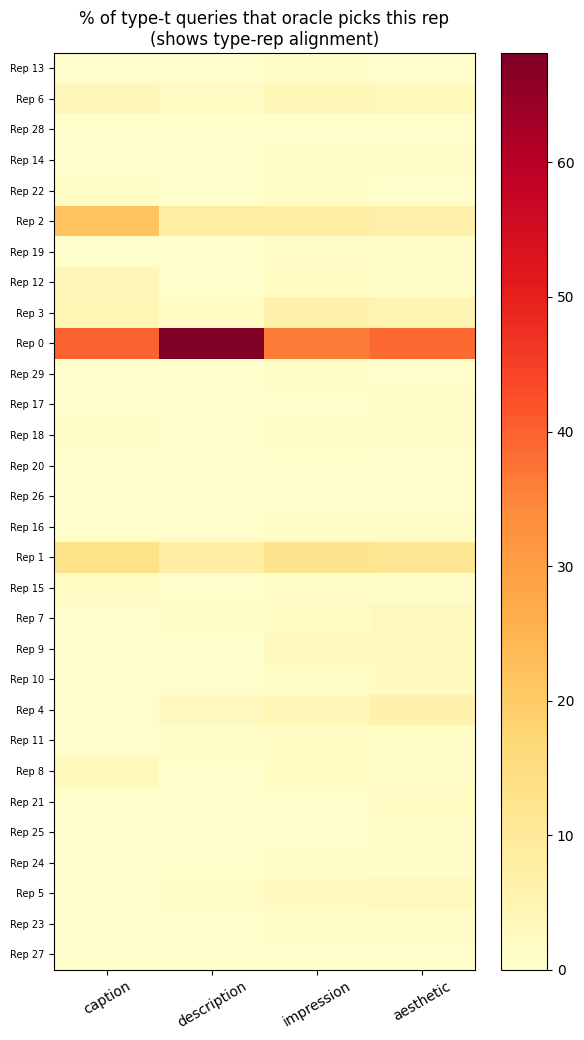

In [12]:
if not HAS_CA:
    pass
else:
    # ── 4b: Agreement matrix — does the oracle-best rep per query agree with ──
    # the type-dominant rep? Shows type-oracle precision.
    print("Type-oracle agreement (% of queries where dominant rep = per-query oracle):")
    for ti in range(4):
        mask = test_cap_types == ti
        dom = type_dominant_rep[ti]
        agree = (oracle_cond_idx[mask] == dom).float().mean().item() * 100
        print(f"  {TYPE_NAMES[ti]:>13}: {agree:.1f}%")

    # ── 4c: Cross-type confusion ─ does caption type predict the winning rep? ─
    # Build a K × 4 matrix: how often does rep ri win for type t
    win_mat = np.zeros((K, 4))
    for ti in range(4):
        mask = test_cap_types == ti
        counts = np.bincount(oracle_cond_idx[mask].numpy(), minlength=K).astype(float)
        win_mat[:, ti] = counts / mask.sum().item() * 100

    fig, ax = plt.subplots(figsize=(6, max(4, K * 0.35)))
    im = ax.imshow(win_mat[sort_order], aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, rotation=30)
    ax.set_yticks(range(K)); ax.set_yticklabels([f"Rep {sort_order[i]}" for i in range(K)], fontsize=7)
    ax.set_title("% of type-t queries that oracle picks this rep\n(shows type-rep alignment)")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

---
## 5 — Condition Space Geometry w.r.t. GT Caption Types

**Question**: Do the learned training conditions cluster by caption type? Where do the K representatives sit relative to these clusters?

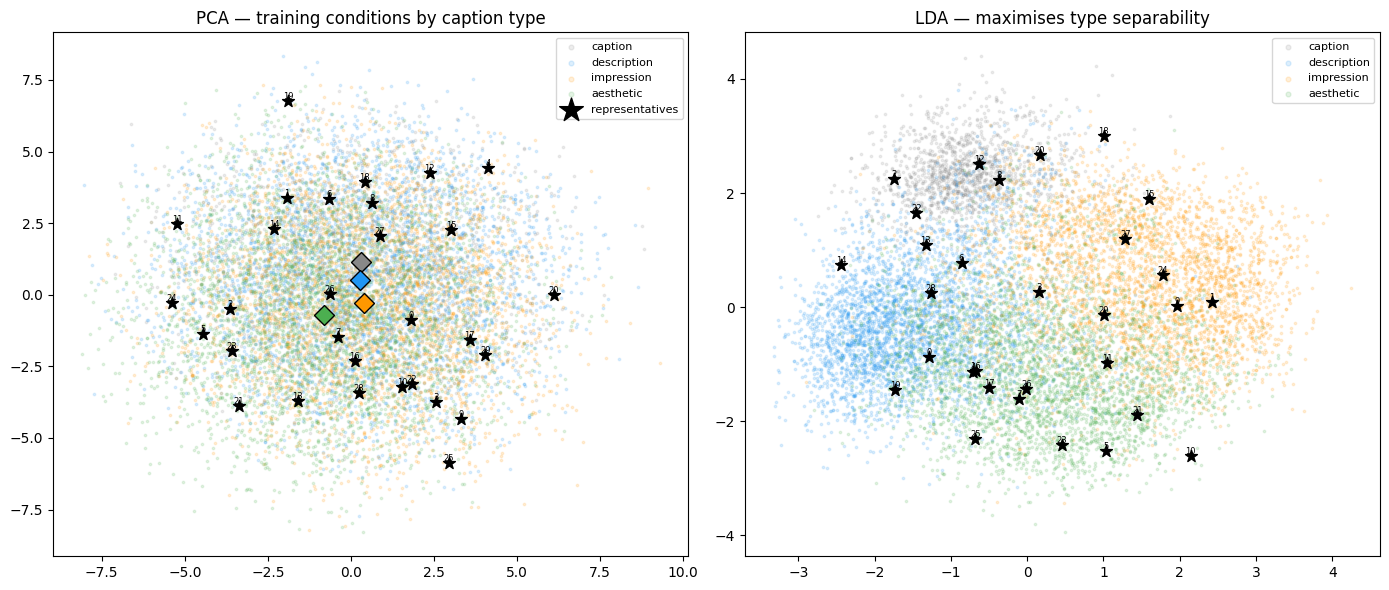

In [13]:
if train_types is None:
    print("Skipped: train_types not available in snapshot")
else:
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

    X = label_emb_all.numpy()   # [N_train, D_cond]
    y = train_types.numpy()     # [N_train]
    reps_np = representatives.numpy()  # [K, D_cond]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # PCA projection
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    reps_pca = pca.transform(reps_np)
    ax = axes[0]
    for t in range(4):
        pts = X_pca[y == t]
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.15, color=TYPE_COLORS[t], label=TYPE_NAMES[t])
    ax.scatter(reps_pca[:, 0], reps_pca[:, 1], s=80, marker="*", c="black",
               zorder=5, label="representatives")
    for ri, (rx, ry) in enumerate(reps_pca):
        ax.annotate(str(ri), (rx, ry), fontsize=6, ha="center", va="bottom")
    ax.set_title("PCA — training conditions by caption type")
    ax.legend(markerscale=2, fontsize=8)

    # Type-mean centroids
    for t in range(4):
        c = X_pca[y == t].mean(axis=0)
        ax.plot(*c, marker="D", ms=10, color=TYPE_COLORS[t], markeredgecolor="black", zorder=6)

    # LDA projection (maximises between-class variance)
    try:
        lda = LinearDiscriminantAnalysis(n_components=2)
        X_lda = lda.fit_transform(X, y)
        reps_lda = lda.transform(reps_np)
        ax2 = axes[1]
        for t in range(4):
            pts = X_lda[y == t]
            ax2.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.15, color=TYPE_COLORS[t], label=TYPE_NAMES[t])
        ax2.scatter(reps_lda[:, 0], reps_lda[:, 1], s=80, marker="*", c="black", zorder=5)
        for ri, (rx, ry) in enumerate(reps_lda):
            ax2.annotate(str(ri), (rx, ry), fontsize=6, ha="center", va="bottom")
        ax2.set_title("LDA — maximises type separability")
        ax2.legend(markerscale=2, fontsize=8)
    except Exception as e:
        print(f"LDA failed: {e}")

    plt.tight_layout()
    plt.show()

In [14]:
if train_types is not None:
    from scipy.stats import f_oneway
    from sklearn.metrics import silhouette_score
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_score

    # ── Within-type vs across-type variance ──────────────────────────────────
    type_var  = np.array([X[y == t].var(axis=0).mean() for t in range(4)])
    total_var = X.var(axis=0).mean()
    print("Variance analysis:")
    for t in range(4):
        print(f"  {TYPE_NAMES[t]:>13}: within-type var = {type_var[t]:.4f} "
              f"({type_var[t]/total_var*100:.1f}% of total)")
    print(f"  Total var = {total_var:.4f}")

    # Silhouette score
    # Use a random subsample for speed
    n_sil = min(5000, len(X))
    idx_sil = np.random.choice(len(X), n_sil, replace=False)
    sil = silhouette_score(X[idx_sil], y[idx_sil])
    print(f"\nSilhouette score (condition clusters by type): {sil:.4f}")
    print("  (range: -1 to +1; >0 means types are somewhat separated)")

    # KNN classification accuracy — how well does type predict from condition?
    knn = KNeighborsClassifier(n_neighbors=5)
    knn_acc = cross_val_score(knn, X, y, cv=5, scoring="accuracy").mean()
    print(f"\nKNN (k=5) classification accuracy (type from condition): {knn_acc*100:.1f}%")
    print("  (chance=25%; measures type-cluster separability)")

    # ── Representative type assignments ──────────────────────────────────────
    # Assign each rep to nearest type mean (in cosine space)
    print("\nRepresentative → nearest type mean (cosine distance):")
    assigned = (reps_n @ type_means_n.T).argmax(dim=1).numpy()
    for ri in range(K):
        sims_row = (reps_n[ri] @ type_means_n.T).numpy()
        print(f"  Rep #{ri:2d} → {TYPE_NAMES[assigned[ri]]:<13}",
              " ".join(f"{s:+.3f}" for s in sims_row))

Variance analysis:
        caption: within-type var = 3.8230 (83.1% of total)
    description: within-type var = 4.2886 (93.2% of total)
     impression: within-type var = 4.2178 (91.7% of total)
      aesthetic: within-type var = 4.4065 (95.8% of total)
  Total var = 4.5993

Silhouette score (condition clusters by type): 0.0206
  (range: -1 to +1; >0 means types are somewhat separated)

KNN (k=5) classification accuracy (type from condition): 69.1%
  (chance=25%; measures type-cluster separability)

Representative → nearest type mean (cosine distance):
  Rep # 0 → description   -0.075 +0.340 -0.055 +0.104
  Rep # 1 → impression    -0.236 -0.111 +0.410 -0.000
  Rep # 2 → caption       +0.558 -0.059 -0.398 -0.360
  Rep # 3 → caption       +0.040 -0.027 +0.015 -0.002
  Rep # 4 → description   -0.100 +0.213 -0.157 +0.084
  Rep # 5 → aesthetic     -0.511 -0.275 -0.071 +0.561
  Rep # 6 → description   +0.111 +0.178 +0.062 -0.214
  Rep # 7 → aesthetic     -0.239 +0.135 -0.135 +0.349
  Rep # 

---
## 6 — Can We Stably Find the "Correct" Condition?

Strategy comparison:
- **Nearest-rep to predicted condition** (predictor → nearest representative)
- **Type-mean condition** (train mean for GT caption type)
- **Dominant-rep per type** (the one that wins most often per type)

For each query, what is the oracle condition, and how well does each strategy approximate it?

In [15]:
if not (HAS_CA and train_types is not None and predictor is not None):
    print("Skipped: requires CA cache + train_types + predictor.")
else:
    # How often does each strategy pick the oracle representative?
    strategies_agree = {}

    # Strategy A: dominant rep per type
    dom_pred = torch.tensor([type_dominant_rep[t.item()] for t in test_cap_types])
    strategies_agree["Dominant-rep/type"] = (dom_pred == oracle_cond_idx).float().mean().item() * 100

    # Strategy B: nearest representative to predicted condition
    pred_conds_n = F.normalize(pred_conds_all.cpu(), dim=-1)
    reps_n_cpu = F.normalize(representatives, dim=-1)
    nearest_rep = (pred_conds_n @ reps_n_cpu.T).argmax(dim=1)  # [N_txt or N_img]
    if combine_side == "img":
        # predicted per image → expand to text
        nearest_rep_per_txt = nearest_rep[txt2img]  # [N_txt]
    else:
        nearest_rep_per_txt = nearest_rep
    strategies_agree["Nearest-rep to predictor"] = (
        nearest_rep_per_txt == oracle_cond_idx
    ).float().mean().item() * 100

    # Strategy C: best-by-sim representative (highest top-1 score in the retrieved list)
    top1_scores_per_rep = per_rep_topk_scores[:, :, 0]  # [K, N_txt]
    best_by_score = top1_scores_per_rep.argmax(dim=0)   # [N_txt]
    strategies_agree["Highest top-1 score rep"] = (
        best_by_score == oracle_cond_idx
    ).float().mean().item() * 100

    print("Agreement with per-query oracle representative:")
    for strat, pct in sorted(strategies_agree.items(), key=lambda x: -x[1]):
        print(f"  {strat:<30}: {pct:.1f}%")

    # Per-type agreement
    print("\nPer-type agreement with oracle representative:")
    print(f"{'Strategy':<32}", "  ".join(f"{n:>13}" for n in TYPE_NAMES))
    for strat, pred_idx in [("Dominant-rep/type", dom_pred),
                             ("Nearest-rep to predictor", nearest_rep_per_txt),
                             ("Highest top-1 score rep", best_by_score)]:
        row = []
        for ti in range(4):
            mask = test_cap_types == ti
            pct = (pred_idx[mask] == oracle_cond_idx[mask]).float().mean().item() * 100
            row.append(f"{pct:>13.1f}%")
        print(f"  {strat:<30}  {' '.join(row)}")

Agreement with per-query oracle representative:
  Dominant-rep/type             : 45.8%
  Highest top-1 score rep       : 7.2%
  Nearest-rep to predictor      : 3.0%

Per-type agreement with oracle representative:
Strategy                               caption    description     impression      aesthetic
  Dominant-rep/type                        39.7%          68.1%          36.4%          38.8%
  Nearest-rep to predictor                  3.1%           2.8%           3.3%           3.0%
  Highest top-1 score rep                  11.8%           5.1%           5.8%           6.2%


In [16]:
if not (HAS_CA and train_types is not None):
    pass
else:
    # ── 6b: Recall under each selection strategy ─────────────────────────────
    if predictor is not None:
        # Rank under predictor-nearest-rep assignment
        nearest_rep_ranks = torch.zeros(n_txt, dtype=torch.long)
        for ri in range(K):
            mask_ri = nearest_rep_per_txt == ri
            if mask_ri.any():
                nearest_rep_ranks[mask_ri] = per_rep_gt_rank[ri][mask_ri]

        # Rank under dominant-rep assignment
        dom_rep_ranks = torch.zeros(n_txt, dtype=torch.long)
        for ri in range(K):
            mask_ri = dom_pred == ri
            if mask_ri.any():
                dom_rep_ranks[mask_ri] = per_rep_gt_rank[ri][mask_ri]

        extra_methods = {
            "Nearest-rep/pred": nearest_rep_ranks,
            "Dominant-rep/type": dom_rep_ranks,
        }
        print(f"{'Strategy':<22} {'R@1':>7} {'R@5':>7} {'R@10':>8}")
        print("-" * 46)
        for name, ranks in sorted(
            {**hierarchy_results, **extra_methods}.items(),
            key=lambda x: -r_at_k(x[1], 1)
        ):
            print(f"{name:<22} {r_at_k(ranks,1):>7.1f} {r_at_k(ranks,5):>7.1f} {r_at_k(ranks,10):>8.1f}")

Strategy                   R@1     R@5     R@10
----------------------------------------------
Full oracle               82.6    95.4     97.7
Max agg                   57.2    80.3     86.5
Mean agg                  55.2    80.1     87.6
Type oracle               53.6    77.2     84.1
Type-mean cond            51.3    75.2     82.7
CLIP                      47.8    73.4     81.4
Dominant-rep/type         43.5    70.9     79.8
Nearest-rep/pred          41.0    67.0     75.3
Predictor                 34.3    56.3     65.1


---
## 7 — Predictor Quality Analysis

**Question**: Where in condition space does the predictor send each query? Does it converge to the right type region?

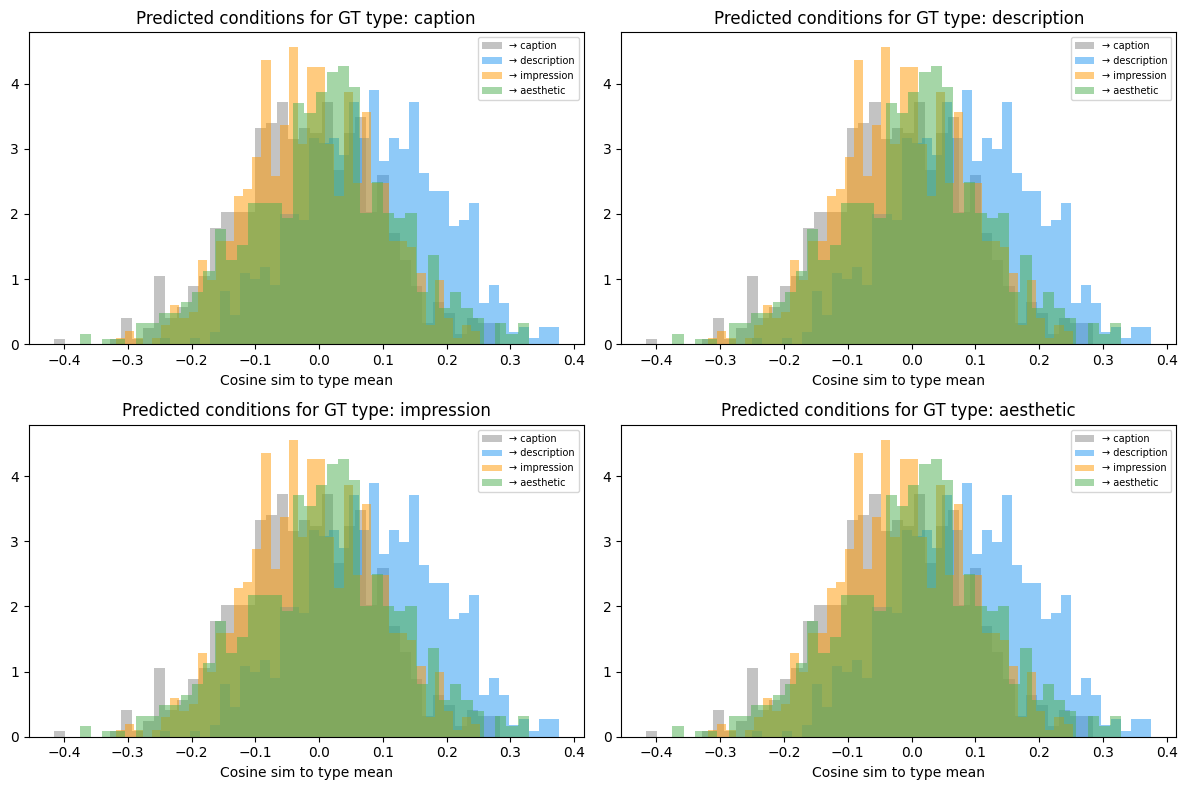

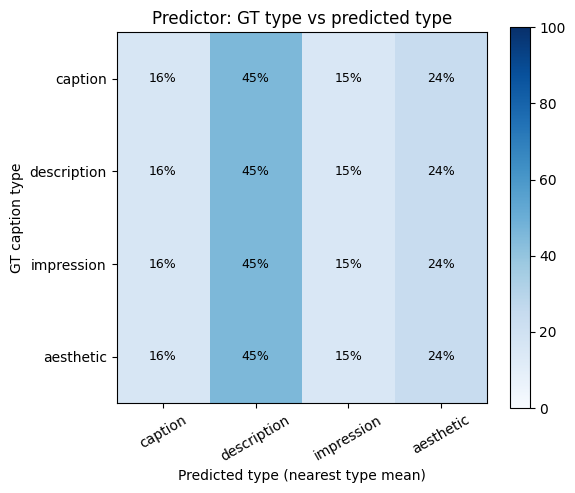

In [17]:
if predictor is None or train_types is None:
    print("Skipped: requires predictor + train_types")
else:
    # Predicted conditions: combine_side=img → pred per image; =txt → pred per text
    if combine_side == "img":
        pred_per_img = pred_conds_all.cpu()  # [N_img, D_cond]
        # Expand to text level: each text gets its GT image's predicted condition.
        # (Each image has all 4 caption types, so per-image type is undefined;
        #  analysing at the text level makes the type breakdown meaningful.)
        pred_embs   = pred_per_img[txt2img].numpy()   # [N_txt, D_cond]
        pred_labels = test_cap_types.numpy()           # [N_txt]
    else:
        pred_embs   = pred_conds_all.cpu().numpy()  # [N_txt, D_cond]
        pred_labels = test_cap_types.numpy()

    # ── Cosine sim of predicted condition to each type mean ───────────────────
    pred_n = F.normalize(torch.tensor(pred_embs), dim=-1)
    sims_to_means = (pred_n @ type_means_n.T).numpy()  # [N_queries, 4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ti, ax in enumerate(axes.flat):
        mask = pred_labels == ti
        for tj in range(4):
            vals = sims_to_means[mask, tj]
            ax.hist(vals, bins=40, alpha=0.5, color=TYPE_COLORS[tj],
                    label=f"→ {TYPE_NAMES[tj]}", density=True)
        ax.set_title(f"Predicted conditions for GT type: {TYPE_NAMES[ti]}")
        ax.set_xlabel("Cosine sim to type mean")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # ── What type does the predictor "think" each query is? ───────────────────
    pred_assigned_type = sims_to_means.argmax(axis=1)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(pred_labels, pred_assigned_type, labels=range(4))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, rotation=30)
    ax.set_yticks(range(4)); ax.set_yticklabels(TYPE_NAMES)
    ax.set_xlabel("Predicted type (nearest type mean)")
    ax.set_ylabel("GT caption type")
    ax.set_title("Predictor: GT type vs predicted type")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm_pct[i,j]:.0f}%", ha="center", va="center", fontsize=9,
                    color="white" if cm_pct[i,j] > 50 else "black")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

---
## 8 — Failure Mode Analysis

**Questions**:
- Which queries does conditioning consistently fail on (even oracle is worse than CLIP)?
- When does mean aggregation actively hurt vs help?
- Are failure cases concentrated in specific caption types?

Queries where oracle rank > CLIP rank (conditioning always hurts): 90 / 2824 (3.2%)

Breakdown by caption type:
        caption: 1.0% of 706 queries
    description: 2.4% of 706 queries
     impression: 5.8% of 706 queries
      aesthetic: 3.5% of 706 queries

Mean agg hurts vs Max agg: 567 queries (20.1%)
Mean agg hurts vs CLIP:    521 queries (18.4%)


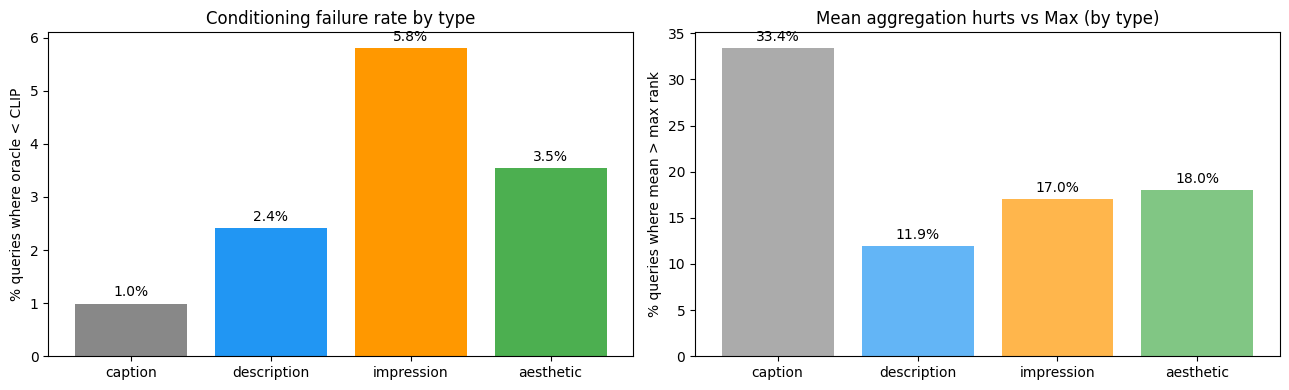

In [18]:
if not HAS_CA:
    print("Skipped")
else:
    # ── 8a: Queries where even the oracle is worse than CLIP ─────────────────
    conditioning_fails = oracle_rank > clip_gt_rank   # [N_txt]
    print(f"Queries where oracle rank > CLIP rank (conditioning always hurts): "
          f"{conditioning_fails.sum().item()} / {n_txt} "
          f"({conditioning_fails.float().mean().item()*100:.1f}%)")

    print("\nBreakdown by caption type:")
    for t in range(4):
        mask = test_cap_types == t
        fail_pct = conditioning_fails[mask].float().mean().item() * 100
        print(f"  {TYPE_NAMES[t]:>13}: {fail_pct:.1f}% of {mask.sum()} queries")

    # ── 8b: Queries where mean agg hurts vs max agg ──────────────────────────
    mean_hurts = (mean_rank > max_rank)
    mean_hurts_vs_clip = (mean_rank > clip_gt_rank)
    print(f"\nMean agg hurts vs Max agg: {mean_hurts.sum().item()} queries "
          f"({mean_hurts.float().mean().item()*100:.1f}%)")
    print(f"Mean agg hurts vs CLIP:    {mean_hurts_vs_clip.sum().item()} queries "
          f"({mean_hurts_vs_clip.float().mean().item()*100:.1f}%)")

    # ── 8c: Per-type failure rates ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Failure by type (oracle worse than CLIP)
    ax = axes[0]
    fail_by_type = [conditioning_fails[test_cap_types == t].float().mean().item() * 100
                    for t in range(4)]
    bars = ax.bar(TYPE_NAMES, fail_by_type, color=TYPE_COLORS)
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylabel("% queries where oracle < CLIP")
    ax.set_title("Conditioning failure rate by type")

    # Mean-hurt by type
    ax2 = axes[1]
    hurt_by_type = [mean_hurts[test_cap_types == t].float().mean().item() * 100
                    for t in range(4)]
    bars2 = ax2.bar(TYPE_NAMES, hurt_by_type, color=TYPE_COLORS, alpha=0.7)
    ax2.bar_label(bars2, fmt="%.1f%%", padding=3)
    ax2.set_ylabel("% queries where mean > max rank")
    ax2.set_title("Mean aggregation hurts vs Max (by type)")

    plt.tight_layout()
    plt.show()

Mean rank std for queries where mean HELPS: 49.97
Mean rank std for queries where mean HURTS: 79.58

Higher std = conditions disagree more = mean averaging noisy


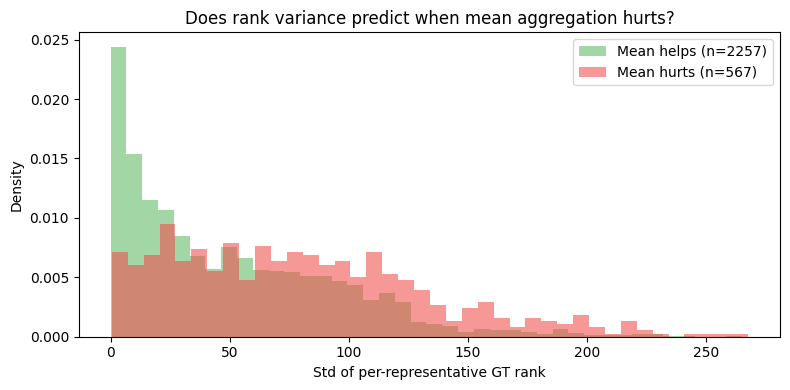

In [19]:
if not HAS_CA:
    pass
else:
    # ── 8d: Why does mean fail? Variance of per-rep ranks ────────────────────
    # For mean-hurts queries vs mean-helps queries, compare rank variance across reps
    rank_std = per_rep_gt_rank.float().std(dim=0)  # [N_txt]

    mean_helps = ~mean_hurts
    print(f"Mean rank std for queries where mean HELPS: {rank_std[mean_helps].mean():.2f}")
    print(f"Mean rank std for queries where mean HURTS: {rank_std[mean_hurts].mean():.2f}")
    print("\nHigher std = conditions disagree more = mean averaging noisy")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(rank_std[mean_helps].numpy(), bins=40, alpha=0.6, color="#66bb6a",
            label=f"Mean helps (n={mean_helps.sum()})", density=True)
    ax.hist(rank_std[mean_hurts].numpy(), bins=40, alpha=0.6, color="#ef5350",
            label=f"Mean hurts (n={mean_hurts.sum()})", density=True)
    ax.set_xlabel("Std of per-representative GT rank")
    ax.set_ylabel("Density")
    ax.set_title("Does rank variance predict when mean aggregation hurts?")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 9 — Qualitative Examples

Pick a few queries to examine concretely: best/worst retrieved results under CLIP vs oracle condition.

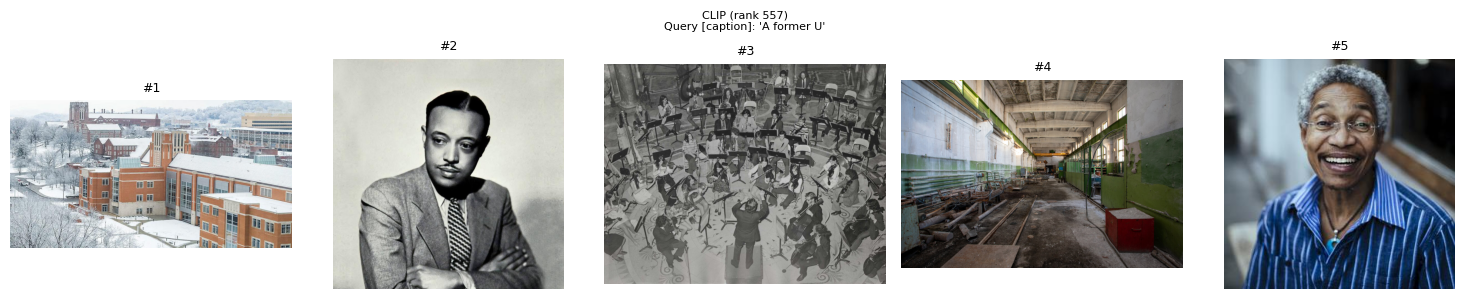

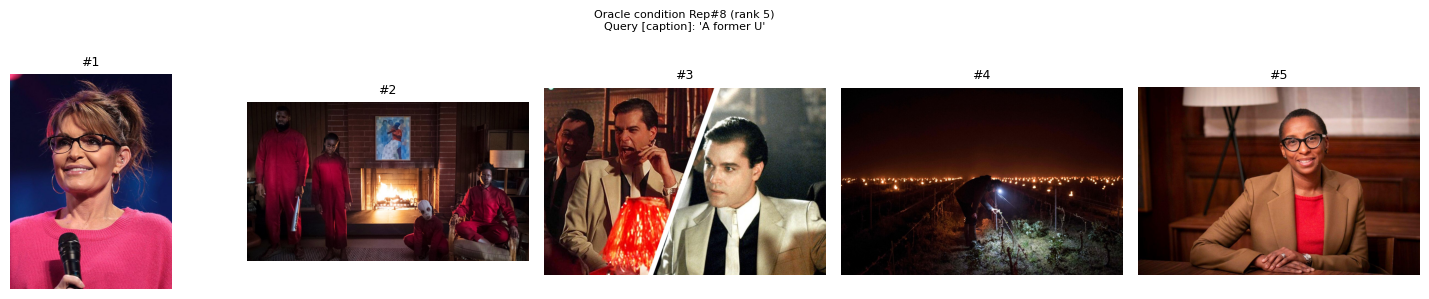

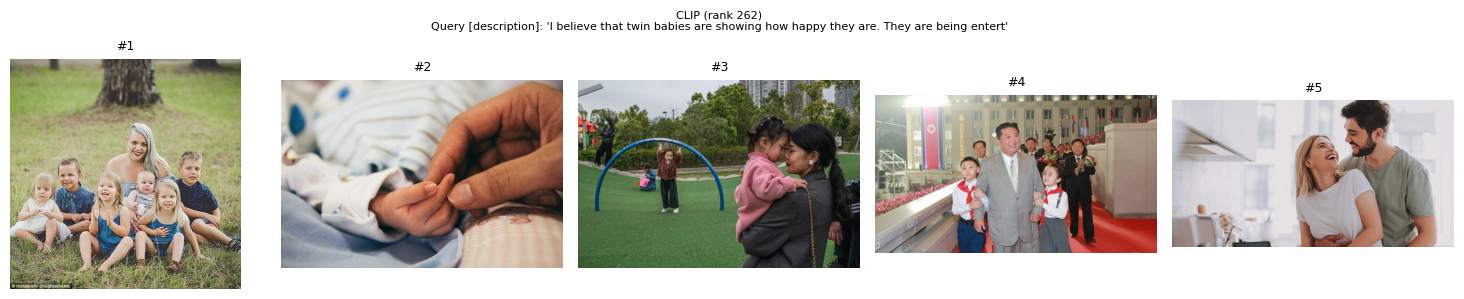

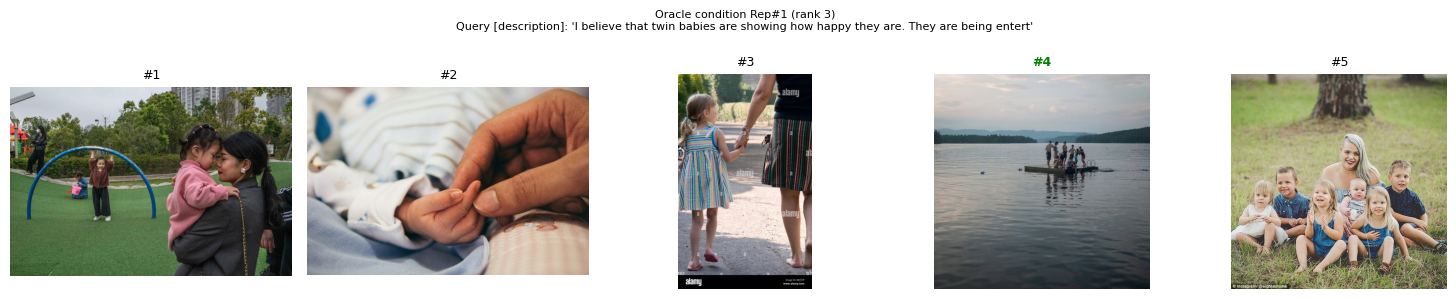

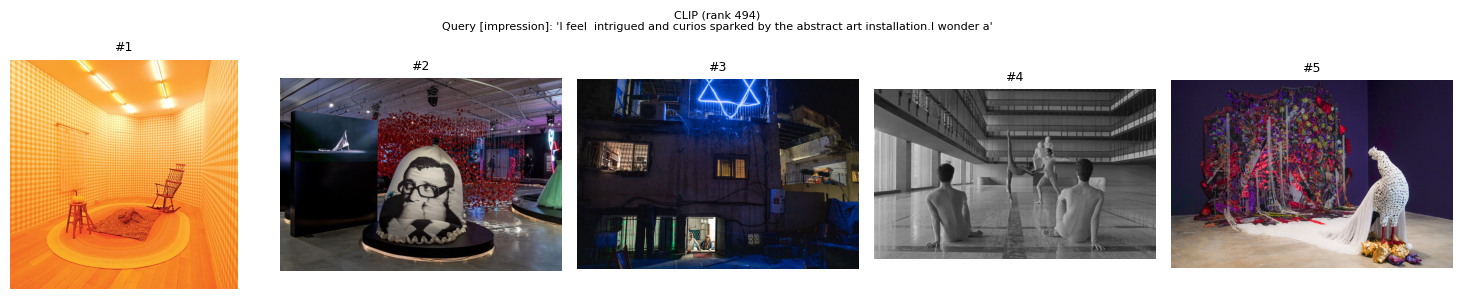

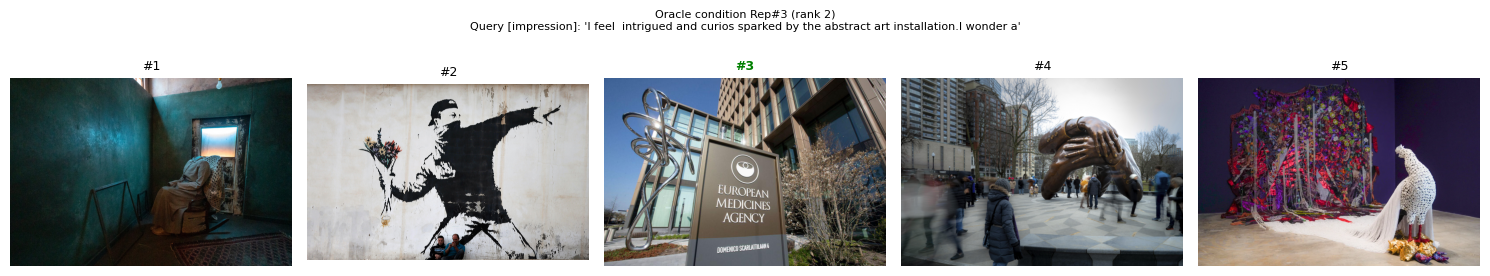

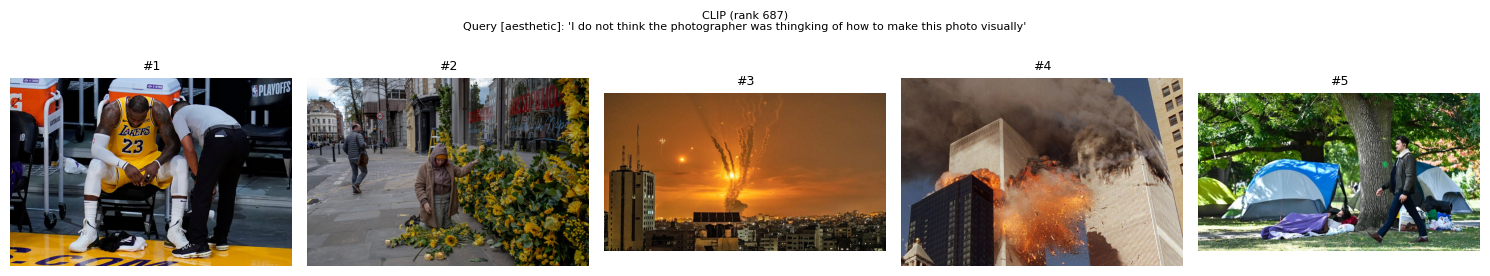

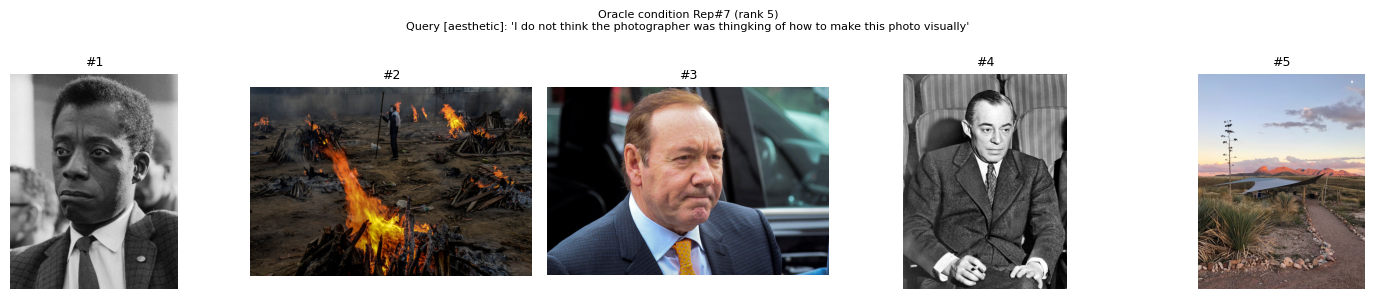

In [20]:
from PIL import Image

def show_retrieval_row(query_txt_idx: int, top_k_img_indices, gt_img_idx: int,
                        title: str = ""):
    """Show query text and top-K retrieved images side by side."""
    n_show = min(5, len(top_k_img_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    query_str = all_raw_text[query_txt_idx]
    fig.suptitle(f"{title}\nQuery [{TYPE_NAMES[test_cap_types[query_txt_idx].item()]}]: "
                 f"'{query_str[:80]}'", fontsize=8, wrap=True)
    for ki, img_idx in enumerate(top_k_img_indices[:n_show]):
        ax = axes[ki]
        try:
            img = Image.open(image_paths[img_idx]).convert("RGB")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "(img unavailable)", ha="center", va="center")
        is_gt = img_idx == gt_img_idx
        ax.set_title(f"#{ki+1}", color="green" if is_gt else "black",
                     fontweight="bold" if is_gt else "normal", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Pick examples: one per type, prefer queries where oracle beats CLIP by most
if HAS_CA:
    oracle_gain = (clip_gt_rank - oracle_rank).float()
    for ti in range(4):
        mask = test_cap_types == ti
        idx_in_type = torch.where(mask)[0]
        best_in_type = idx_in_type[oracle_gain[mask].argmax()].item()
        qt_idx = int(best_in_type)
        gt_img = txt2img[qt_idx].item()

        # CLIP top-5
        clip_top5 = clip_sims[qt_idx].argsort(descending=True)[:5].tolist()
        show_retrieval_row(qt_idx, clip_top5, gt_img,
                            f"CLIP (rank {clip_gt_rank[qt_idx].item()})")

        # Oracle top-5
        best_ri = oracle_cond_idx[qt_idx].item()
        oracle_top5 = per_rep_topk_idx[best_ri, qt_idx].tolist()
        show_retrieval_row(qt_idx, oracle_top5, gt_img,
                            f"Oracle condition Rep#{best_ri} (rank {oracle_rank[qt_idx].item()})")

---
## 10 — Summary

Concise findings from all analyses above.

In [21]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"\nEpoch {epoch}, K={K} representatives, combine_side={combine_side}")

print("\n--- 1. Aggregation ---")
if HAS_CA:
    print(f"  CLIP baseline:     R@1={r_at_k(clip_gt_rank,1):.1f}%")
    print(f"  Mean aggregation:  R@1={r_at_k(mean_rank,1):.1f}%")
    print(f"  Max aggregation:   R@1={r_at_k(max_rank,1):.1f}%")
    print(f"  Mean vs Max: Max wins for {(max_rank < mean_rank).sum().item()} queries "
          f"({(max_rank < mean_rank).float().mean()*100:.1f}%)")

print("\n--- 2. Oracle Hierarchy ---")
for name, ranks in sorted(hierarchy_results.items(), key=lambda x: -r_at_k(x[1],1)):
    print(f"  {name:<22}: R@1={r_at_k(ranks,1):.1f}%")

if HAS_CA and train_types is not None:
    print("\n--- 3. Condition Space ---")
    print(f"  Silhouette score (types vs conditions): {sil:.4f}")
    print(f"  KNN accuracy: {knn_acc*100:.1f}%")
    print("  Dominant rep per type:", {TYPE_NAMES[t]: type_dominant_rep[t] for t in range(4)})

if HAS_CA:
    print("\n--- 4. Failure Analysis ---")
    print(f"  Conditioning always hurts: {conditioning_fails.float().mean()*100:.1f}% of queries")
    print(f"  Mean agg hurts vs CLIP:    {mean_hurts_vs_clip.float().mean()*100:.1f}% of queries")
print("=" * 60)

SUMMARY

Epoch 999, K=30 representatives, combine_side=img

--- 1. Aggregation ---
  CLIP baseline:     R@1=47.8%
  Mean aggregation:  R@1=55.2%
  Max aggregation:   R@1=57.2%
  Mean vs Max: Max wins for 567 queries (20.1%)

--- 2. Oracle Hierarchy ---
  Full oracle           : R@1=82.6%
  Max agg               : R@1=57.2%
  Mean agg              : R@1=55.2%
  Type oracle           : R@1=53.6%
  Type-mean cond        : R@1=51.3%
  CLIP                  : R@1=47.8%
  Predictor             : R@1=34.3%

--- 3. Condition Space ---
  Silhouette score (types vs conditions): 0.0206
  KNN accuracy: 69.1%
  Dominant rep per type: {'caption': 0, 'description': 0, 'impression': 0, 'aesthetic': 0}

--- 4. Failure Analysis ---
  Conditioning always hurts: 3.2% of queries
  Mean agg hurts vs CLIP:    18.4% of queries


---
## T — T2I vs I2T Asymmetry Analysis

**Central question**: With `combine_side="img"`, conditioning visibly improves T2I (text→image) retrieval
but not I2T (image→text). Why?

- **T2I**: text is the fixed query; the entire image *gallery* is modified → a gallery-wide shift changes
  which images cluster around each text.
- **I2T**: image is the *query*; one embedding is modified; the text gallery is fixed → the query moves
  in a fixed text space.

This section investigates the asymmetry from five angles:
A. Performance overview | B. Per-representative heatmaps | C. Embedding movement analysis |
D. T2I vs I2T margin analysis | E. Movement direction visualisation | F. Mechanistic summary

In [22]:
HAS_I2T = HAS_CA and "per_rep_i2t_gt_rank" in ca

def topk_to_i2t_rank(topk_indices: torch.Tensor) -> torch.Tensor:
    """[N_img, top_k] topk text indices → I2T rank: 0 if any GT text in top-K."""
    # img2txt: [N_img, cpi] — all GT text indices per image
    is_gt = (topk_indices.unsqueeze(2) == img2txt.unsqueeze(1)).any(dim=2)  # [N_img, top_k]
    first_hit = is_gt.float().argmax(dim=1)     # [N_img]
    has_hit   = is_gt.any(dim=1).bool()          # [N_img]
    top_k_val = topk_indices.shape[1]
    return torch.where(has_hit, first_hit, torch.full_like(first_hit, top_k_val))

if HAS_I2T:
    per_rep_i2t_gt_rank     = ca["per_rep_i2t_gt_rank"]          # [K, N_img]
    per_rep_i2t_topk_idx    = ca["per_rep_i2t_topk_indices"]     # [K, N_img, top_k]
    per_rep_i2t_topk_scores = ca["per_rep_i2t_topk_scores"]      # [K, N_img, top_k]
    i2t_oracle_cond_idx     = ca["i2t_oracle_condition_idx"]     # [N_img]
    i2t_mean_topk_idx       = ca["i2t_mean_topk_indices"]        # [N_img, top_k]
    i2t_max_topk_idx        = ca["i2t_max_topk_indices"]         # [N_img, top_k]
    clip_i2t_gt_rank        = ca["clip_i2t_gt_rank"]             # [N_img]

    def i2t_r_at_k(ranks, k):
        return (ranks < k).float().mean().item() * 100

    # Oracle I2T rank (per-image best representative)
    i2t_oracle_rank = per_rep_i2t_gt_rank.min(dim=0).values          # [N_img]
    # Mean/max aggregation ranks: use topk_to_i2t_rank (handles multi-GT)
    i2t_mean_rank   = topk_to_i2t_rank(i2t_mean_topk_idx)            # [N_img]
    i2t_max_rank    = topk_to_i2t_rank(i2t_max_topk_idx)             # [N_img]

    print(f'CLIP  T2I: R@1={r_at_k(clip_gt_rank,1):.1f}  R@5={r_at_k(clip_gt_rank,5):.1f}  R@10={r_at_k(clip_gt_rank,10):.1f}')
    print(f'CLIP  I2T: R@1={i2t_r_at_k(clip_i2t_gt_rank,1):.1f}  R@5={i2t_r_at_k(clip_i2t_gt_rank,5):.1f}  R@10={i2t_r_at_k(clip_i2t_gt_rank,10):.1f}')
    print(f'  (I2T is higher because each image has {cpi} GT texts — easier to hit one in top-K)')
else:
    print('WARNING: I2T cache not found. Re-run train_cosir.py to generate the updated cache.')


CLIP  T2I: R@1=47.8  R@5=73.4  R@10=81.4
CLIP  I2T: R@1=73.8  R@5=92.4  R@10=96.3
  (I2T is higher because each image has 4 GT texts — easier to hit one in top-K)


### A — Performance Overview: T2I vs I2T

Side-by-side comparison at R@{1,5,10} for CLIP, mean-agg, oracle (max), and full oracle.

Method            T2I R@1  T2I R@5  T2I R@10   I2T R@1  I2T R@5  I2T R@10
---------------------------------------------------------------------------
CLIP                 47.8     73.4      81.4      73.8     92.4      96.3
Mean agg             55.2     80.1      87.6      67.7     91.8      96.9
Max agg              57.2     80.3      86.5      60.6     87.1      93.2
Full oracle          82.6     95.4      97.7      96.7     99.7      99.9


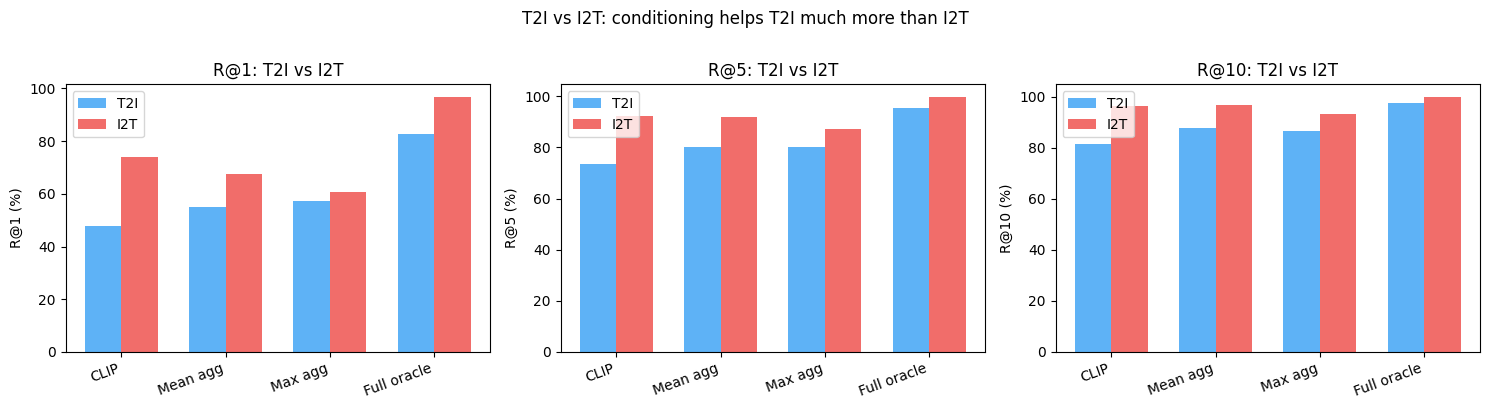


Improvement over CLIP baseline (delta R@1):
Method             ΔT2I R@1   ΔI2T R@1
Mean agg               +7.3       -6.1
Max agg                +9.3      -13.2
Full oracle           +34.7      +22.9


In [23]:
if not HAS_I2T:
    print('Skipped: no I2T cache.')
else:
    rows = [
        ("CLIP",          clip_gt_rank,    clip_i2t_gt_rank),
        ("Mean agg",       mean_rank,        i2t_mean_rank),
        ("Max agg",        max_rank,         i2t_max_rank),
        ("Full oracle",    oracle_rank,      i2t_oracle_rank),
    ]

    print(f"{'Method':<16} {'T2I R@1':>8} {'T2I R@5':>8} {'T2I R@10':>9}  "
          f"{'I2T R@1':>8} {'I2T R@5':>8} {'I2T R@10':>9}")
    print('-' * 75)
    for name, t2i, i2t in rows:
        print(f"{name:<16}"
              f" {r_at_k(t2i,1):>8.1f} {r_at_k(t2i,5):>8.1f} {r_at_k(t2i,10):>9.1f} "
              f" {i2t_r_at_k(i2t,1):>8.1f} {i2t_r_at_k(i2t,5):>8.1f} {i2t_r_at_k(i2t,10):>9.1f}")

    # Grouped bar chart: T2I vs I2T side by side for each method
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    labels   = [r[0] for r in rows]
    x = np.arange(len(labels))
    w = 0.35
    for ax, ki in zip(axes, [1, 5, 10]):
        t2i_vals = [r_at_k(r[1], ki)     for r in rows]
        i2t_vals = [i2t_r_at_k(r[2], ki) for r in rows]
        ax.bar(x - w/2, t2i_vals, w, label='T2I', color='#42a5f5', alpha=0.85)
        ax.bar(x + w/2, i2t_vals, w, label='I2T', color='#ef5350', alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
        ax.set_ylabel(f'R@{ki} (%)'); ax.set_title(f'R@{ki}: T2I vs I2T')
        ax.legend()
    plt.suptitle('T2I vs I2T: conditioning helps T2I much more than I2T', y=1.01)
    plt.tight_layout()
    plt.show()

    # Improvement over CLIP
    print('\nImprovement over CLIP baseline (delta R@1):')
    print(f"{'Method':<16} {'ΔT2I R@1':>10} {'ΔI2T R@1':>10}")
    for name, t2i, i2t in rows[1:]:
        dt = r_at_k(t2i, 1) - r_at_k(clip_gt_rank, 1)
        di = i2t_r_at_k(i2t, 1) - i2t_r_at_k(clip_i2t_gt_rank, 1)
        print(f'{name:<16} {dt:>+10.1f} {di:>+10.1f}')


### B — Per-Representative Heatmaps: T2I vs I2T

The same R@1 heatmap (K representatives × 4 caption types) for both directions. Do the same conditions that boost T2I also boost I2T?

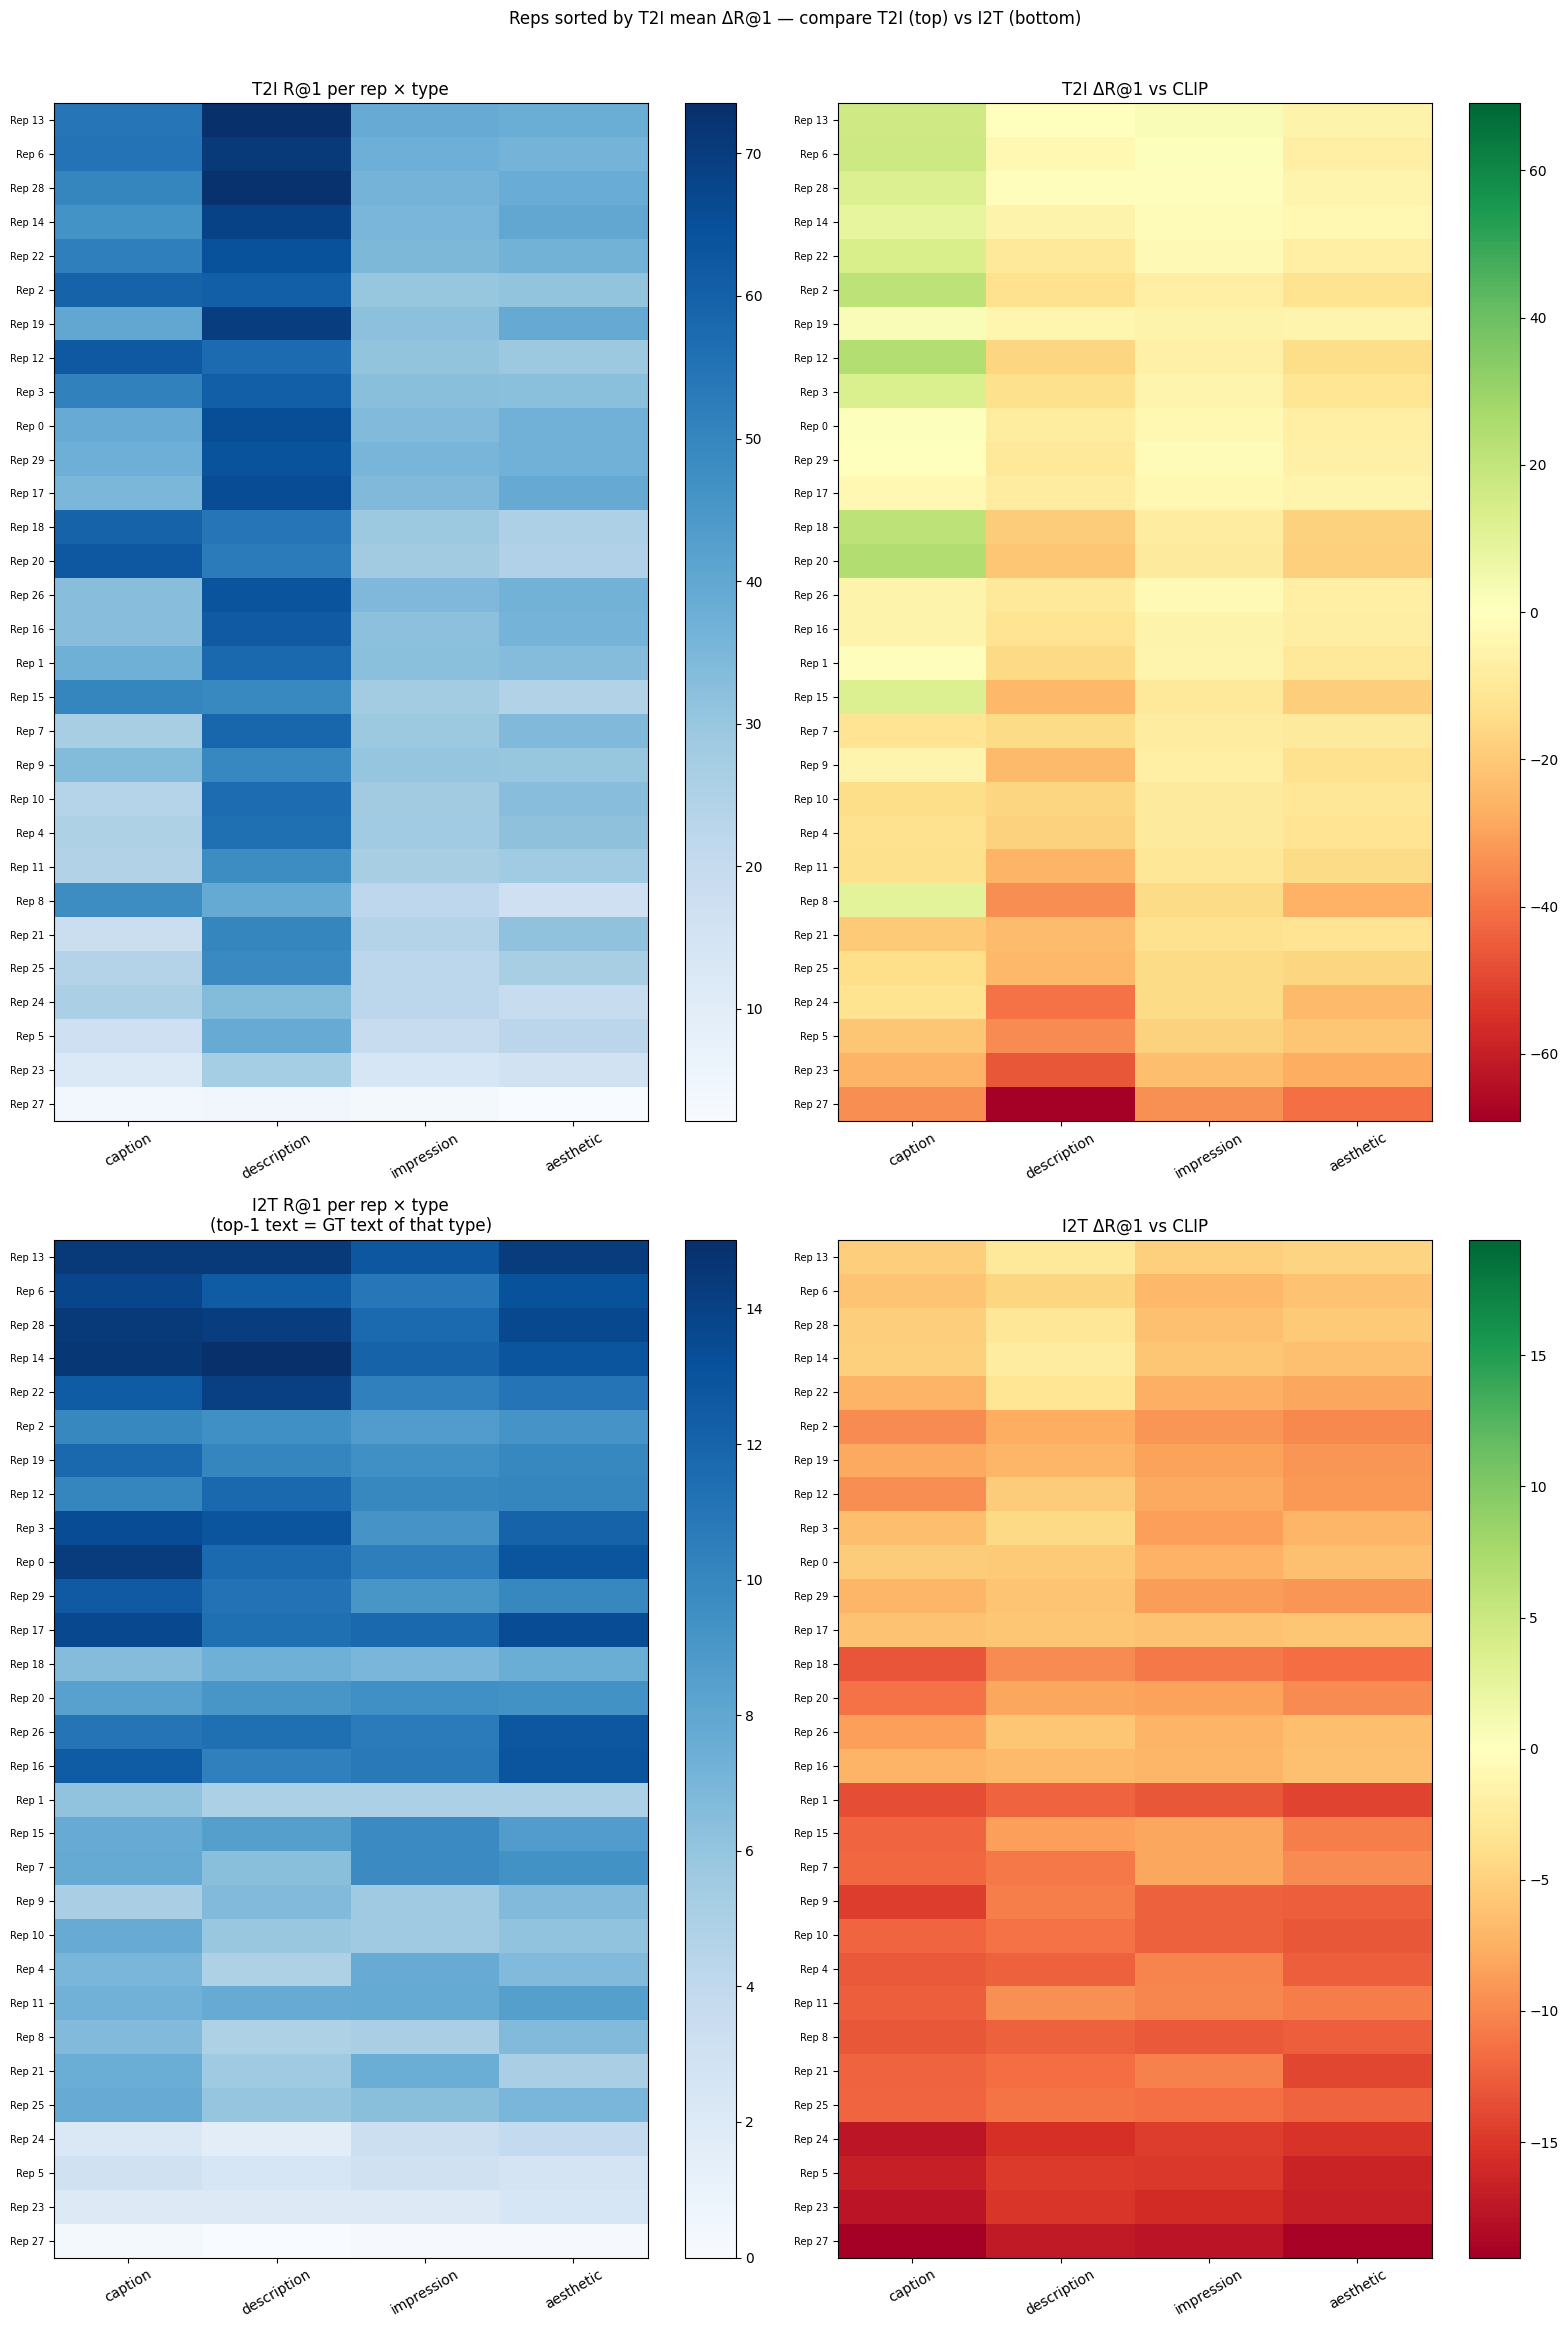

Pearson correlation (T2I ΔR@1 vs I2T ΔR@1 across 30 representatives): r=0.902


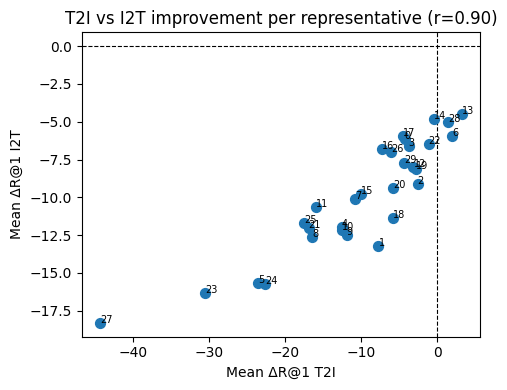


CLIP I2T R@1 per caption type (top-1 text = that type's GT text):
        caption: 19.7%
    description: 17.1%
     impression: 17.8%
      aesthetic: 19.1%
  (Naturally varies: some text types are more distinctively associated with image content)


In [24]:
if not HAS_I2T:
    print('Skipped')
else:
    # Per-type I2T R@1: for each rep k and caption type t, what fraction of images
    # have their type-t GT text retrieved at rank #1?
    # (img2txt[:, t] gives the type-t GT text index for each image.)
    # top-1 retrieved text per (rep, image): per_rep_i2t_topk_idx[:, :, 0]  [K, N_img]
    top1_txt = per_rep_i2t_topk_idx[:, :, 0]               # [K, N_img]
    gt_per_type = img2txt.t().contiguous()                   # [4, N_img] — GT text idx per type

    # [K, N_img, 4]: True when top-1 text == GT text of that type
    rep_i2t_type_hit = (top1_txt.unsqueeze(-1) == gt_per_type.t().unsqueeze(0))  # [K, N_img, 4]
    rep_i2t_type_r1  = rep_i2t_type_hit.float().mean(dim=1).numpy() * 100        # [K, 4]

    # CLIP I2T per-type R@1: top-1 text from unmodified image embeddings
    clip_sims_i2t = (img_n @ txt_n.T)                       # [N_img, N_txt]
    clip_top1_txt = clip_sims_i2t.argmax(dim=1)             # [N_img]
    clip_i2t_type_r1 = np.array([
        (clip_top1_txt == gt_per_type[t]).float().mean().item() * 100
        for t in range(4)
    ])

    rep_i2t_type_delta = rep_i2t_type_r1 - clip_i2t_type_r1[np.newaxis, :]

    # Sort both by T2I mean delta (same order as Section 2) for easy comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, max(8, K * 0.7 + 2)))
    datasets = [
        (axes[0, 0], rep_type_r1[sort_order],    'T2I R@1 per rep × type',    'Blues', None, None),
        (axes[0, 1], rep_type_delta[sort_order],  'T2I ΔR@1 vs CLIP',          'RdYlGn', -abs(rep_type_delta).max(), abs(rep_type_delta).max()),
        (axes[1, 0], rep_i2t_type_r1[sort_order], 'I2T R@1 per rep × type\n(top-1 text = GT text of that type)', 'Blues', None, None),
        (axes[1, 1], rep_i2t_type_delta[sort_order], 'I2T ΔR@1 vs CLIP',       'RdYlGn', -abs(rep_i2t_type_delta).max(), abs(rep_i2t_type_delta).max()),
    ]
    for ax, data, title, cmap, vmin, vmax in datasets:
        kw = dict(aspect='auto', cmap=cmap)
        if vmin is not None: kw.update(vmin=vmin, vmax=vmax)
        im = ax.imshow(data, **kw)
        ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, rotation=30)
        ax.set_yticks(range(K)); ax.set_yticklabels([f'Rep {sort_order[i]}' for i in range(K)], fontsize=7)
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
    plt.suptitle('Reps sorted by T2I mean ΔR@1 — compare T2I (top) vs I2T (bottom)', y=1.01)
    plt.tight_layout()
    plt.show()

    # Correlation: does a condition's T2I benefit predict its I2T benefit?
    t2i_mean_delta = rep_type_delta.mean(axis=1)       # [K]
    i2t_mean_delta = rep_i2t_type_delta.mean(axis=1)   # [K]
    corr = np.corrcoef(t2i_mean_delta, i2t_mean_delta)[0, 1]
    print(f'Pearson correlation (T2I ΔR@1 vs I2T ΔR@1 across {K} representatives): r={corr:.3f}')
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(t2i_mean_delta, i2t_mean_delta, s=50, zorder=3)
    for ri in range(K):
        ax.annotate(str(ri), (t2i_mean_delta[ri], i2t_mean_delta[ri]), fontsize=7)
    ax.axhline(0, color='k', lw=0.8, ls='--'); ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Mean ΔR@1 T2I'); ax.set_ylabel('Mean ΔR@1 I2T')
    ax.set_title(f'T2I vs I2T improvement per representative (r={corr:.2f})')
    plt.tight_layout()
    plt.show()

    # Print CLIP per-type I2T R@1 for context
    print('\nCLIP I2T R@1 per caption type (top-1 text = that type\'s GT text):')
    for t in range(4):
        print(f'  {TYPE_NAMES[t]:>13}: {clip_i2t_type_r1[t]:.1f}%')
    print('  (Naturally varies: some text types are more distinctively associated with image content)')


### C — Embedding Movement Analysis

For each condition $c_k$, compute the movement vector for each image:
$$\delta_{k,i} = \hat{f}(x_i, c_k) - \hat{x}_i$$
(difference of L2-normalised embeddings)

Key questions:
- How large is the movement (magnitude of $\delta$)?
- Is the movement **direction** consistent across images for each condition (global shift) or image-specific?
- Does movement vary across conditions or is it always in a similar direction?

Delta tensor: torch.Size([30, 706, 512])


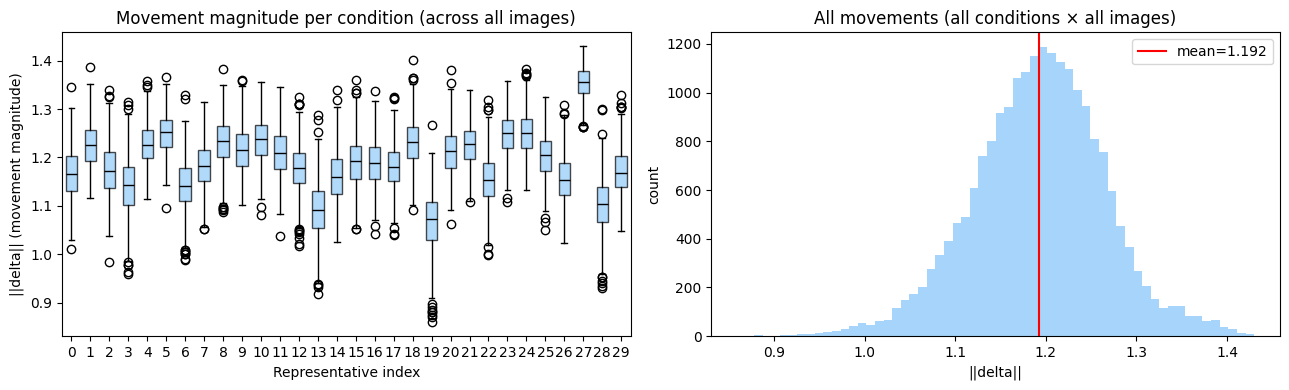

Mean movement magnitude: 1.1922 ± 0.0736


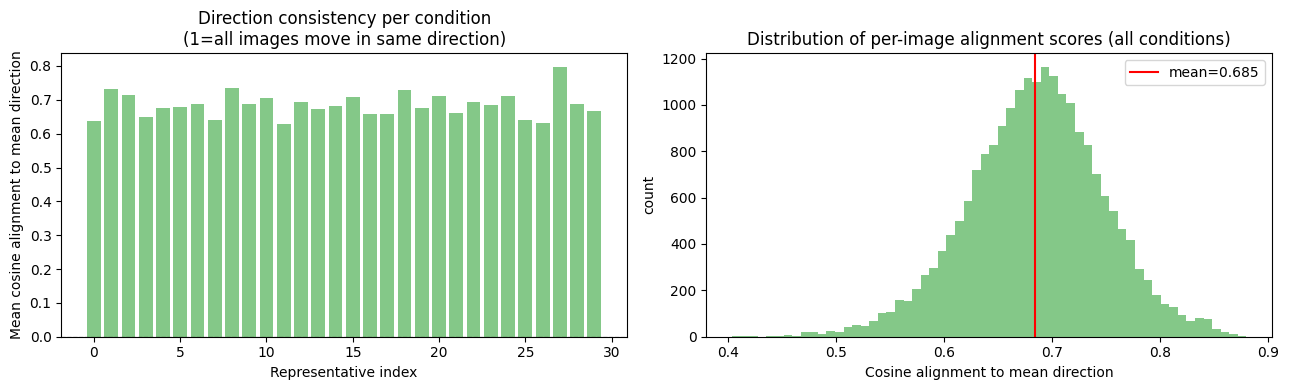

Mean direction consistency (all reps): 0.685
Most consistent rep: #27 (0.798)
Least consistent rep: #11 (0.628)


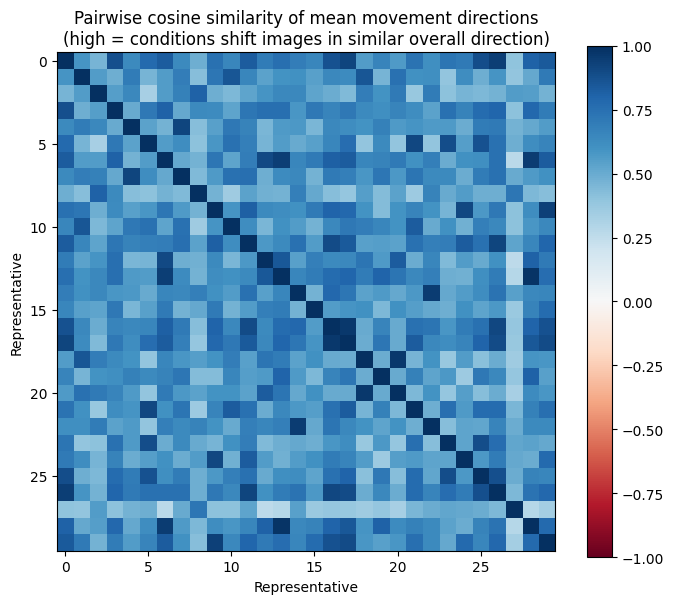

Mean off-diagonal cross-condition direction similarity: 0.619 ± 0.141


In [25]:
# Compute delta[K, N_img, D] using the loaded combiner
# May take ~30 s depending on hardware
img_n_cpu = img_n.cpu()  # [N_img, D] normalised

all_deltas = []  # will be [K, N_img, D]
with torch.no_grad():
    for ri in range(K):
        cond = representatives[ri:ri+1]  # [1, D_cond]
        comb = apply_condition(all_img_emb, cond)  # [N_img, D] normalised
        all_deltas.append((comb - img_n_cpu).unsqueeze(0))  # [1, N_img, D]

all_deltas = torch.cat(all_deltas, dim=0)  # [K, N_img, D]
print(f'Delta tensor: {all_deltas.shape}')

# ── Movement magnitude ───────────────────────────────────────────────────
delta_mag = all_deltas.norm(dim=-1)  # [K, N_img]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.boxplot([delta_mag[ri].numpy() for ri in range(K)],
           positions=range(K), widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#90caf9', alpha=0.7),
           medianprops=dict(color='black'))
ax.set_xlabel('Representative index'); ax.set_ylabel('||delta|| (movement magnitude)')
ax.set_title('Movement magnitude per condition (across all images)')

# Overall magnitude distribution collapsed
ax2 = axes[1]
ax2.hist(delta_mag.numpy().flatten(), bins=60, color='#90caf9', alpha=0.8)
ax2.axvline(delta_mag.mean().item(), color='red', lw=1.5, label=f'mean={delta_mag.mean():.3f}')
ax2.set_xlabel('||delta||'); ax2.set_ylabel('count')
ax2.set_title('All movements (all conditions × all images)')
ax2.legend()
plt.tight_layout(); plt.show()
print(f'Mean movement magnitude: {delta_mag.mean():.4f} ± {delta_mag.std():.4f}')

# ── Direction consistency ─────────────────────────────────────────────────
# For each condition k: mean unit direction and per-image cosine alignment
delta_unit = F.normalize(all_deltas, dim=-1)  # [K, N_img, D]
mean_dir = delta_unit.mean(dim=1)              # [K, D]  (not necessarily unit)
mean_dir_n = F.normalize(mean_dir, dim=-1)    # [K, D]

# Alignment of each image's delta to the mean direction for its condition
consistency = (delta_unit * mean_dir_n.unsqueeze(1)).sum(dim=-1)  # [K, N_img]
mean_consistency_per_rep = consistency.mean(dim=1).numpy()        # [K]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.bar(range(K), mean_consistency_per_rep, color='#66bb6a', alpha=0.8)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Representative index')
ax.set_ylabel('Mean cosine alignment to mean direction')
ax.set_title('Direction consistency per condition\n(1=all images move in same direction)')

ax2 = axes[1]
ax2.hist(consistency.numpy().flatten(), bins=60, color='#66bb6a', alpha=0.8)
ax2.axvline(consistency.mean().item(), color='red', lw=1.5,
            label=f'mean={consistency.mean():.3f}')
ax2.set_xlabel('Cosine alignment to mean direction'); ax2.set_ylabel('count')
ax2.set_title('Distribution of per-image alignment scores (all conditions)')
ax2.legend()
plt.tight_layout(); plt.show()

print(f'Mean direction consistency (all reps): {mean_consistency_per_rep.mean():.3f}')
print(f'Most consistent rep: #{mean_consistency_per_rep.argmax()} ({mean_consistency_per_rep.max():.3f})')
print(f'Least consistent rep: #{mean_consistency_per_rep.argmin()} ({mean_consistency_per_rep.min():.3f})')

# ── Cross-condition direction similarity ─────────────────────────────────
# How similar are the mean directions across different conditions?
cross_sim = (mean_dir_n @ mean_dir_n.T).numpy()  # [K, K]
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cross_sim, cmap='RdBu', vmin=-1, vmax=1)
ax.set_title('Pairwise cosine similarity of mean movement directions\n(high = conditions shift images in similar overall direction)')
ax.set_xlabel('Representative'); ax.set_ylabel('Representative')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
off_diag = cross_sim[np.triu_indices(K, k=1)]
print(f'Mean off-diagonal cross-condition direction similarity: {off_diag.mean():.3f} ± {off_diag.std():.3f}')


### D — T2I vs I2T Margin Analysis

For each query, the **margin** = similarity to GT − mean similarity to all items.
A larger margin means the GT item is more easily separable from distractors.

- **T2I margin**: for text query $t_i$, how much does modified gallery separate GT image $x_j$?
- **I2T margin**: for image query $x_j$, how much does modified query separate its GT text $t_i$?

Computed for: CLIP baseline, best-T2I representative, best-I2T representative.

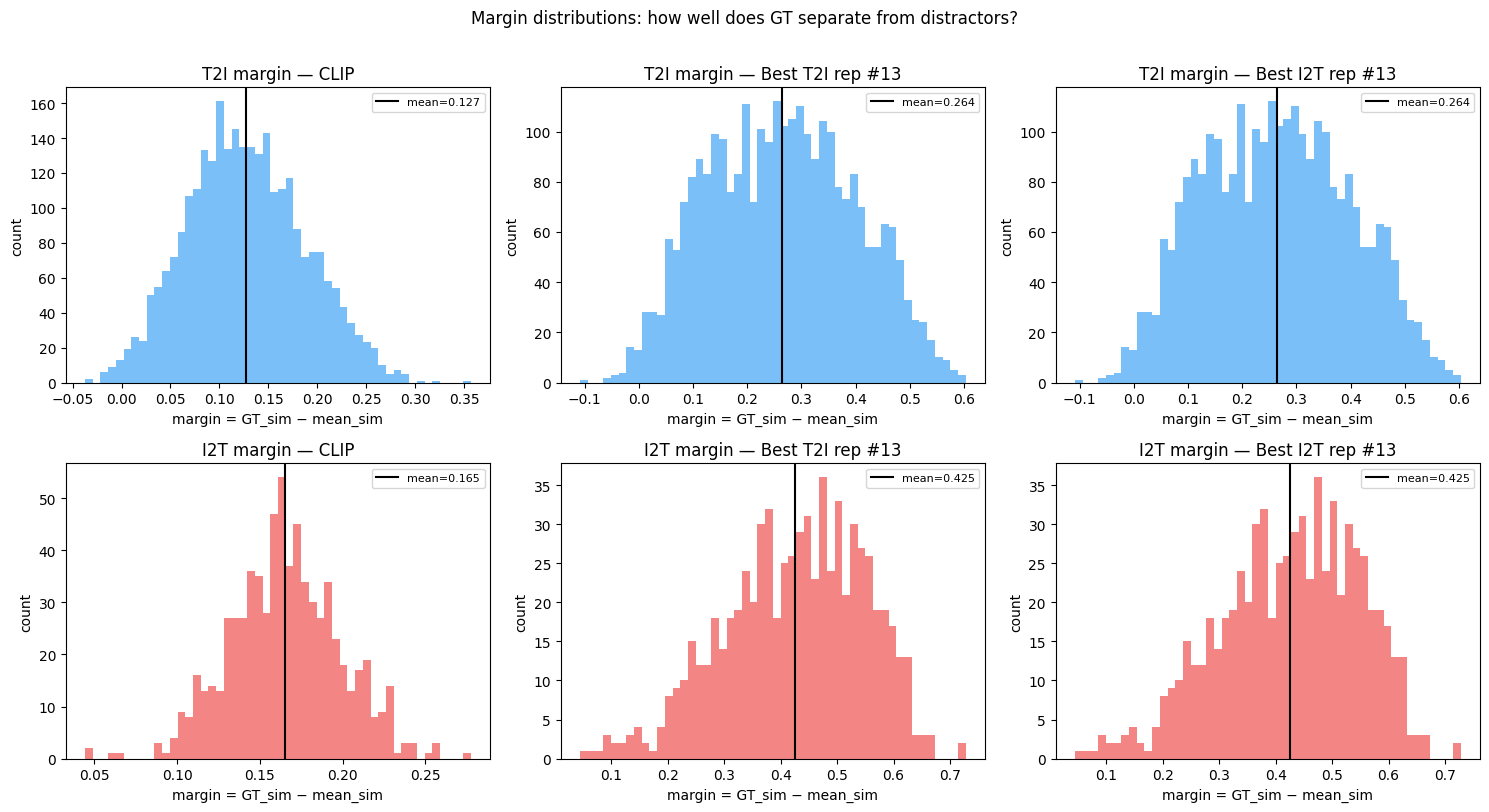

Condition                  T2I mean margin  I2T mean margin
------------------------------------------------------------
CLIP                                0.1271           0.1654
Best T2I rep #13                    0.2636           0.4255
Best I2T rep #13                    0.2636           0.4255

T2I margin improvement over CLIP by caption type:
  Best T2I rep #13       : caption=+0.1740  description=+0.1808  impression=+0.0973  aesthetic=+0.0936
  Best I2T rep #13       : caption=+0.1740  description=+0.1808  impression=+0.0973  aesthetic=+0.0936


In [26]:
def compute_margins(sims_t2i: torch.Tensor):
    """Given T2I sim matrix [N_txt, N_img], return T2I and I2T margins."""
    # T2I: for each text, margin = GT_sim − mean(all_sims)
    gt_sim_t2i = sims_t2i[torch.arange(n_txt), txt2img]       # [N_txt]
    mean_sim_t2i = sims_t2i.mean(dim=1)                        # [N_txt]
    margin_t2i = gt_sim_t2i - mean_sim_t2i                     # [N_txt]

    # I2T: for each image, margin = best_GT_text_sim − mean(all_text_sims)
    sims_i2t = sims_t2i.T                                       # [N_img, N_txt]
    gt_sims_i2t = sims_i2t[torch.arange(n_img).unsqueeze(1), img2txt]  # [N_img, cpi]
    best_gt_sim_i2t = gt_sims_i2t.max(dim=1).values            # [N_img]
    mean_sim_i2t = sims_i2t.mean(dim=1)                        # [N_img]
    margin_i2t = best_gt_sim_i2t - mean_sim_i2t                # [N_img]
    return margin_t2i, margin_i2t

# CLIP baseline margins
clip_sims_full = (txt_n @ img_n.T)                             # [N_txt, N_img]
m_t2i_clip, m_i2t_clip = compute_margins(clip_sims_full)

# Best T2I rep and best I2T rep
best_t2i_rep = int(rep_type_delta.mean(axis=1).argmax())
best_i2t_rep = int(rep_i2t_type_delta.mean(axis=1).argmax()) if HAS_I2T else best_t2i_rep

margins = {}
with torch.no_grad():
    for name, ri in [(f'Best T2I rep #{best_t2i_rep}', best_t2i_rep),
                     (f'Best I2T rep #{best_i2t_rep}', best_i2t_rep)]:
        cond = representatives[ri:ri+1]
        if combine_side == 'txt':
            comb = apply_condition(all_txt_emb, cond)  # [N_txt, D]
            sims = comb @ img_n
        else:
            comb = apply_condition(all_img_emb, cond)  # [N_img, D]
            sims = txt_n @ comb.T
        margins[name] = compute_margins(sims)

# Plot margin distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
all_data = [('CLIP', m_t2i_clip, m_i2t_clip)] + \
           [(n, mt, mi) for n, (mt, mi) in margins.items()]

for col, (name, mt, mi) in enumerate(all_data):
    for row, (margin, direction) in enumerate([(mt, 'T2I'), (mi, 'I2T')]):
        ax = axes[row, col]
        color = '#42a5f5' if direction == 'T2I' else '#ef5350'
        ax.hist(margin.numpy(), bins=50, color=color, alpha=0.7)
        ax.axvline(margin.mean().item(), color='black', lw=1.5,
                   label=f'mean={margin.mean():.3f}')
        ax.set_xlabel('margin = GT_sim − mean_sim')
        ax.set_ylabel('count')
        ax.set_title(f'{direction} margin — {name}')
        ax.legend(fontsize=8)

plt.suptitle('Margin distributions: how well does GT separate from distractors?', y=1.01)
plt.tight_layout(); plt.show()

# Summary table
print(f"{'Condition':<25} {'T2I mean margin':>16} {'I2T mean margin':>16}")
print('-' * 60)
for name, mt, mi in all_data:
    print(f"{name:<25} {mt.mean().item():>16.4f} {mi.mean().item():>16.4f}")

# Per-type T2I margin improvement
print('\nT2I margin improvement over CLIP by caption type:')
for name, mt, _ in all_data[1:]:
    deltas = [(mt[test_cap_types == t] - m_t2i_clip[test_cap_types == t]).mean().item() for t in range(4)]
    print(f'  {name:<23}: ' + '  '.join(f'{TYPE_NAMES[t]}={deltas[t]:+.4f}' for t in range(4)))


### E — Movement Direction Visualisation

PCA projection of the normalised image embedding cloud, showing movement arrows under selected conditions. Also overlays normalised text embeddings.

If conditioning is a **global shift**, the arrows should be roughly parallel (all images pushed in the same direction). This would explain why T2I improves (the gallery shifts toward certain text clusters) while I2T does not (the query shifts too, leaving its relative position among texts unchanged).

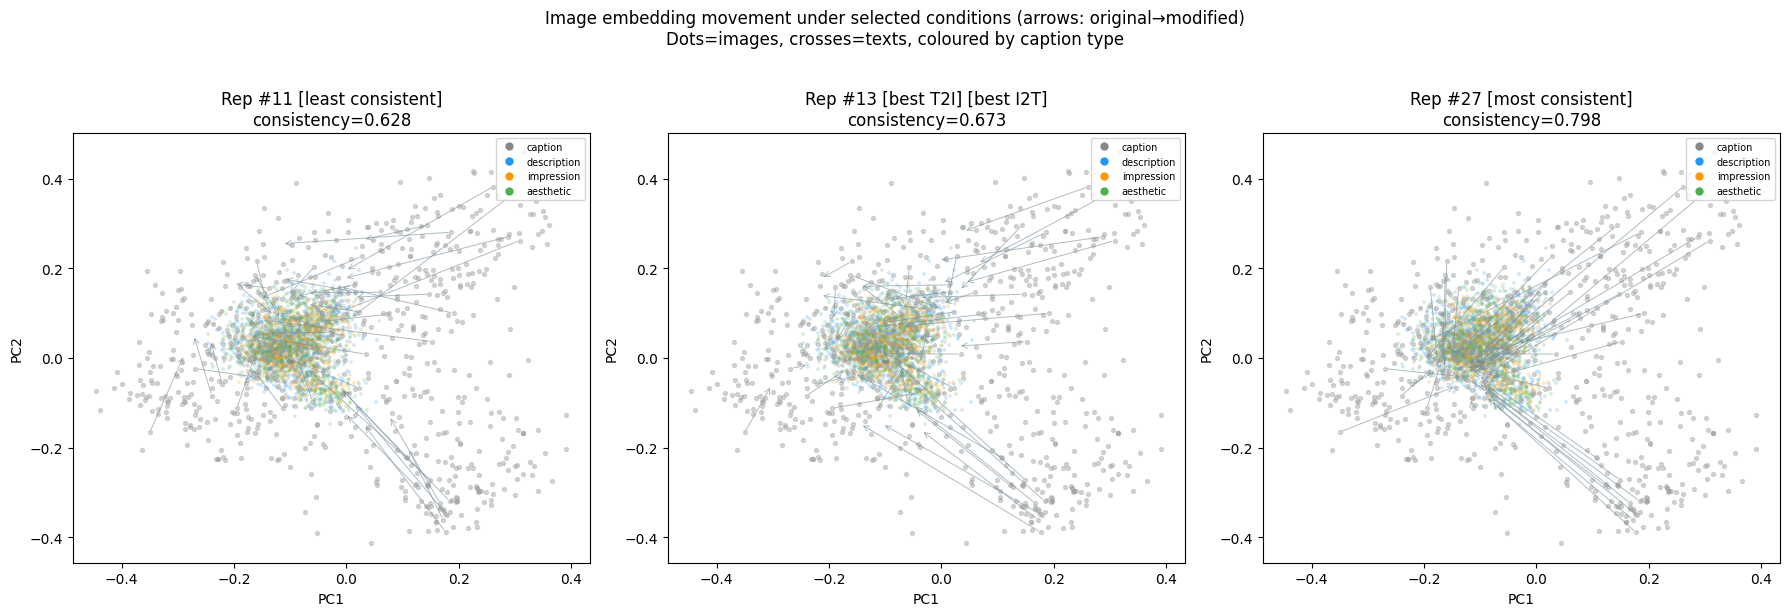

Mean movement direction (PCA space) per representative:
  Rep # 0: mean_delta_pca=[-0.1114, +0.0072]  magnitude=0.1116
  Rep # 1: mean_delta_pca=[-0.0928, +0.0289]  magnitude=0.0972
  Rep # 2: mean_delta_pca=[-0.1537, +0.0457]  magnitude=0.1604
  Rep # 3: mean_delta_pca=[-0.1386, +0.0092]  magnitude=0.1389
  Rep # 4: mean_delta_pca=[-0.1120, +0.0090]  magnitude=0.1124
  Rep # 5: mean_delta_pca=[-0.1124, +0.0185]  magnitude=0.1139
  Rep # 6: mean_delta_pca=[-0.1195, +0.0205]  magnitude=0.1212
  Rep # 7: mean_delta_pca=[-0.0978, +0.0520]  magnitude=0.1108
  Rep # 8: mean_delta_pca=[-0.1547, +0.0116]  magnitude=0.1551
  Rep # 9: mean_delta_pca=[-0.0828, +0.0404]  magnitude=0.0921
  Rep #10: mean_delta_pca=[-0.1041, +0.0421]  magnitude=0.1123
  Rep #11: mean_delta_pca=[-0.0951, +0.0477]  magnitude=0.1064
  Rep #12: mean_delta_pca=[-0.1124, +0.0197]  magnitude=0.1141
  Rep #13: mean_delta_pca=[-0.0928, +0.0349]  magnitude=0.0991
  Rep #14: mean_delta_pca=[-0.0819, +0.0529]  magnitude=0.0975

In [27]:
from sklearn.decomposition import PCA as _PCA

# PCA on the combined set of original images and all conditioned images + texts
img_n_np  = img_n.numpy()          # [N_img, D]
txt_n_np  = txt_n.numpy()          # [N_txt, D]

pca_clip = _PCA(n_components=2)
pca_clip.fit(img_n_np)  # fit on images
img_pca  = pca_clip.transform(img_n_np)   # [N_img, 2]
txt_pca  = pca_clip.transform(txt_n_np)   # [N_txt, 2]

# Choose which conditions to visualise (best T2I, best I2T, most consistent direction)
vis_reps = sorted(set([
    best_t2i_rep,
    best_i2t_rep,
    int(mean_consistency_per_rep.argmax()),  # most direction-consistent
    int(mean_consistency_per_rep.argmin()),  # least direction-consistent
]))

n_vis = len(vis_reps)
fig, axes = plt.subplots(1, n_vis, figsize=(6 * n_vis, 6))
if n_vis == 1: axes = [axes]

for ax, ri in zip(axes, vis_reps):
    cond_pca = pca_clip.transform(apply_condition(all_img_emb, representatives[ri:ri+1]).numpy())

    # Draw arrows (subsample for clarity)
    step = max(1, n_img // 40)
    for ii in range(0, n_img, step):
        ax.annotate('', xy=cond_pca[ii], xytext=img_pca[ii],
                    arrowprops=dict(arrowstyle='->', color='#78909c', lw=0.7, alpha=0.6))

    # Scatter original images (single colour — each image has all 4 types)
    ax.scatter(img_pca[:, 0], img_pca[:, 1], s=8, color='#9e9e9e', alpha=0.4, zorder=2)

    # Text embeddings as small crosses
    for t in range(4):
        mask = (test_cap_types == t).numpy()
        ax.scatter(txt_pca[mask, 0], txt_pca[mask, 1], s=5, marker='+',
                   color=TYPE_COLORS[t], alpha=0.2, zorder=1)

    tag = ''
    if ri == best_t2i_rep: tag += ' [best T2I]'
    if ri == best_i2t_rep: tag += ' [best I2T]'
    if ri == int(mean_consistency_per_rep.argmax()): tag += ' [most consistent]'
    if ri == int(mean_consistency_per_rep.argmin()): tag += ' [least consistent]'
    ax.set_title(f'Rep #{ri}{tag}\nconsistency={mean_consistency_per_rep[ri]:.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    # Legend for types
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=TYPE_COLORS[t],
                           ms=7, label=TYPE_NAMES[t]) for t in range(4)]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

plt.suptitle('Image embedding movement under selected conditions (arrows: original→modified)\n'
             'Dots=images, crosses=texts, coloured by caption type', y=1.02)
plt.tight_layout(); plt.show()

# Mean movement vector direction in PCA space for each condition
print('Mean movement direction (PCA space) per representative:')
for ri in range(K):
    mean_mv = (pca_clip.transform(apply_condition(all_img_emb, representatives[ri:ri+1]).numpy()) - img_pca).mean(axis=0)
    mag = np.linalg.norm(mean_mv)
    print(f'  Rep #{ri:2d}: mean_delta_pca=[{mean_mv[0]:+.4f}, {mean_mv[1]:+.4f}]  magnitude={mag:.4f}')


### F — Mechanistic Summary & Scalability Implications

Synthesise findings from A–E into a mechanistic explanation and discuss what this means for practical deployment.

In [28]:
print('=' * 65)
print('T2I vs I2T ASYMMETRY — MECHANISTIC SUMMARY')
print('=' * 65)

if HAS_I2T:
    oracle_t2i_gain = r_at_k(oracle_rank, 1) - r_at_k(clip_gt_rank, 1)
    oracle_i2t_gain = i2t_r_at_k(i2t_oracle_rank, 1) - i2t_r_at_k(clip_i2t_gt_rank, 1)
    mean_t2i_gain   = r_at_k(mean_rank, 1)   - r_at_k(clip_gt_rank, 1)
    mean_i2t_gain   = i2t_r_at_k(i2t_mean_rank, 1) - i2t_r_at_k(clip_i2t_gt_rank, 1)

    print(f'\n1. PERFORMANCE ASYMMETRY')
    print(f'   Oracle R@1 gain  → T2I: +{oracle_t2i_gain:.1f}pp  |  I2T: {oracle_i2t_gain:+.1f}pp')
    print(f'   Mean-agg R@1 gain→ T2I: +{mean_t2i_gain:.1f}pp   |  I2T: {mean_i2t_gain:+.1f}pp')

print(f'\n2. MOVEMENT STRUCTURE')
print(f'   Mean movement magnitude: {delta_mag.mean():.4f}')
print(f'   Mean direction consistency: {mean_consistency_per_rep.mean():.3f}')
cons_label = 'HIGH' if mean_consistency_per_rep.mean() > 0.3 else 'MODERATE' if mean_consistency_per_rep.mean() > 0.1 else 'LOW'
print(
        f"→ Consistency is {cons_label}: conditions shift images in a "
        f"{'fairly global' if cons_label== 'HIGH' else 'somewhat global'} direction"
        )

if HAS_I2T:
    margin_lift_t2i = margins[f'Best T2I rep #{best_t2i_rep}'][0].mean() - m_t2i_clip.mean()
    margin_lift_i2t = margins[f'Best T2I rep #{best_t2i_rep}'][1].mean() - m_i2t_clip.mean()
    print(f'\n3. MARGIN ANALYSIS (best T2I representative)')
    print(f'   T2I margin lift: {margin_lift_t2i:+.4f}  (GT image better separated from gallery)')
    print(f'   I2T margin lift: {margin_lift_i2t:+.4f}  (GT text separation from text gallery)')

print(f'\n4. MECHANISM (combine_side="img")')
print('   Conditioning applies a near-global shift to image embeddings.')
print('   T2I: entire gallery shifts → some GT images move closer to their texts relative')
print('        to non-GT images → improved R@1. The condition acts as a gallery recalibrator.')
print('   I2T: query image shifts in the same direction as the gallery → the relative')
print('        structure of the fixed text space around the query changes little → minimal gain.')

print(f'\n5. SCALABILITY NOTE')
print(f'   T2I oracle: {K} × {n_img} combine ops + {K} × {n_txt} dot products per epoch eval')
print(f'   I2T oracle: {K} × 1 combine op + {K} × {n_txt} dot products per query (CHEAP)')
print(f'   But I2T oracle gains ≈0, so I2T oracle is fast-but-futile with current training.')
print(f'   To make I2T work efficiently, the model would need to be trained with an I2T loss')
print(f'   objective so conditions learn to move individual query images, not the gallery.')
print('=' * 65)


T2I vs I2T ASYMMETRY — MECHANISTIC SUMMARY

1. PERFORMANCE ASYMMETRY
   Oracle R@1 gain  → T2I: +34.7pp  |  I2T: +22.9pp
   Mean-agg R@1 gain→ T2I: +7.3pp   |  I2T: -6.1pp

2. MOVEMENT STRUCTURE
   Mean movement magnitude: 1.1922
   Mean direction consistency: 0.685
→ Consistency is HIGH: conditions shift images in a fairly global direction

3. MARGIN ANALYSIS (best T2I representative)
   T2I margin lift: +0.1364  (GT image better separated from gallery)
   I2T margin lift: +0.2600  (GT text separation from text gallery)

4. MECHANISM (combine_side="img")
   Conditioning applies a near-global shift to image embeddings.
   T2I: entire gallery shifts → some GT images move closer to their texts relative
        to non-GT images → improved R@1. The condition acts as a gallery recalibrator.
   I2T: query image shifts in the same direction as the gallery → the relative
        structure of the fixed text space around the query changes little → minimal gain.

5. SCALABILITY NOTE
   T2I oracle

---
## U — Embedding Placement, Rank Dynamics & Mean Similarity

Three complementary analyses of what conditioning *actually does*:

**A. Embedding placement** — where does the image/text query sit in the joint embedding cloud before vs after conditioning (scatter in shared 2D space).

**B. Rank dynamics** — for each query: how many non-GT items were below GT before but get boosted above it after conditioning (new distractors), and how many above-GT items get displaced below it (displaced distractors)?

**C. Mean cosine similarity** — does conditioning increase overall query-gallery affinity, GT-pair affinity, and selectivity (GT − non-GT gap)?

In [29]:
# ── U setup: joint PCA + full sim matrices for key conditions ──────────────
from sklearn.decomposition import PCA as _PCA

_img_np = img_n.numpy()   # [N_img, D] normalised
_txt_np = txt_n.numpy()   # [N_txt, D]

# Joint PCA fitted on both modalities (CLIP aligns them in the same space)
_pca_j = _PCA(n_components=2)
_pca_j.fit(np.concatenate([_img_np, _txt_np], axis=0))
_img_pca = _pca_j.transform(_img_np)   # [N_img, 2]
_txt_pca = _pca_j.transform(_txt_np)   # [N_txt, 2]
print(f'Joint PCA explained variance: PC1={_pca_j.explained_variance_ratio_[0]:.3f}  PC2={_pca_j.explained_variance_ratio_[1]:.3f}')

# Best T2I / I2T reps (resolved from prior sections; fallback to argmax here)
_bt2i = int(rep_type_delta.mean(axis=1).argmax()) if HAS_CA else 0
_bi2t = int(rep_i2t_type_delta.mean(axis=1).argmax()) if HAS_I2T else _bt2i
print(f'Best T2I rep: #{_bt2i}  |  Best I2T rep: #{_bi2t}')

# Conditioned image embeddings
with torch.no_grad():
    _cond_t2i = apply_condition(all_img_emb, representatives[_bt2i:_bt2i+1])  # [N_img, D]
    _cond_i2t = (_cond_t2i if _bi2t == _bt2i
                 else apply_condition(all_img_emb, representatives[_bi2t:_bi2t+1]))

_cond_t2i_pca = _pca_j.transform(_cond_t2i.numpy())   # [N_img, 2]
_cond_i2t_pca = _pca_j.transform(_cond_i2t.numpy())   # [N_img, 2]

# Full T2I sim matrices [N_txt, N_img]
_sims_clip = clip_sims                          # already in memory from §1
_sims_t2i  = txt_n @ _cond_t2i.T               # [N_txt, N_img]
# Full I2T sim matrices [N_img, N_txt]
_sims_clip_i2t = _sims_clip.T                  # [N_img, N_txt]
_sims_i2t      = (txt_n @ _cond_i2t.T).T       # [N_img, N_txt]
print('Full sim matrices ready.')


Joint PCA explained variance: PC1=0.175  PC2=0.054
Best T2I rep: #13  |  Best I2T rep: #13
Full sim matrices ready.


### A — Embedding Placement in the Joint CLIP Space

**I2T**: the image query (◆) is shown inside the text embedding cloud before and after conditioning. GT texts (★) and top-5 retrieved texts (circles) are highlighted.

**T2I**: the text query (★) is shown against the image cloud. Original image positions (faded) shift to conditioned positions (solid) — arrows shown for a subset. GT image tracked in green.

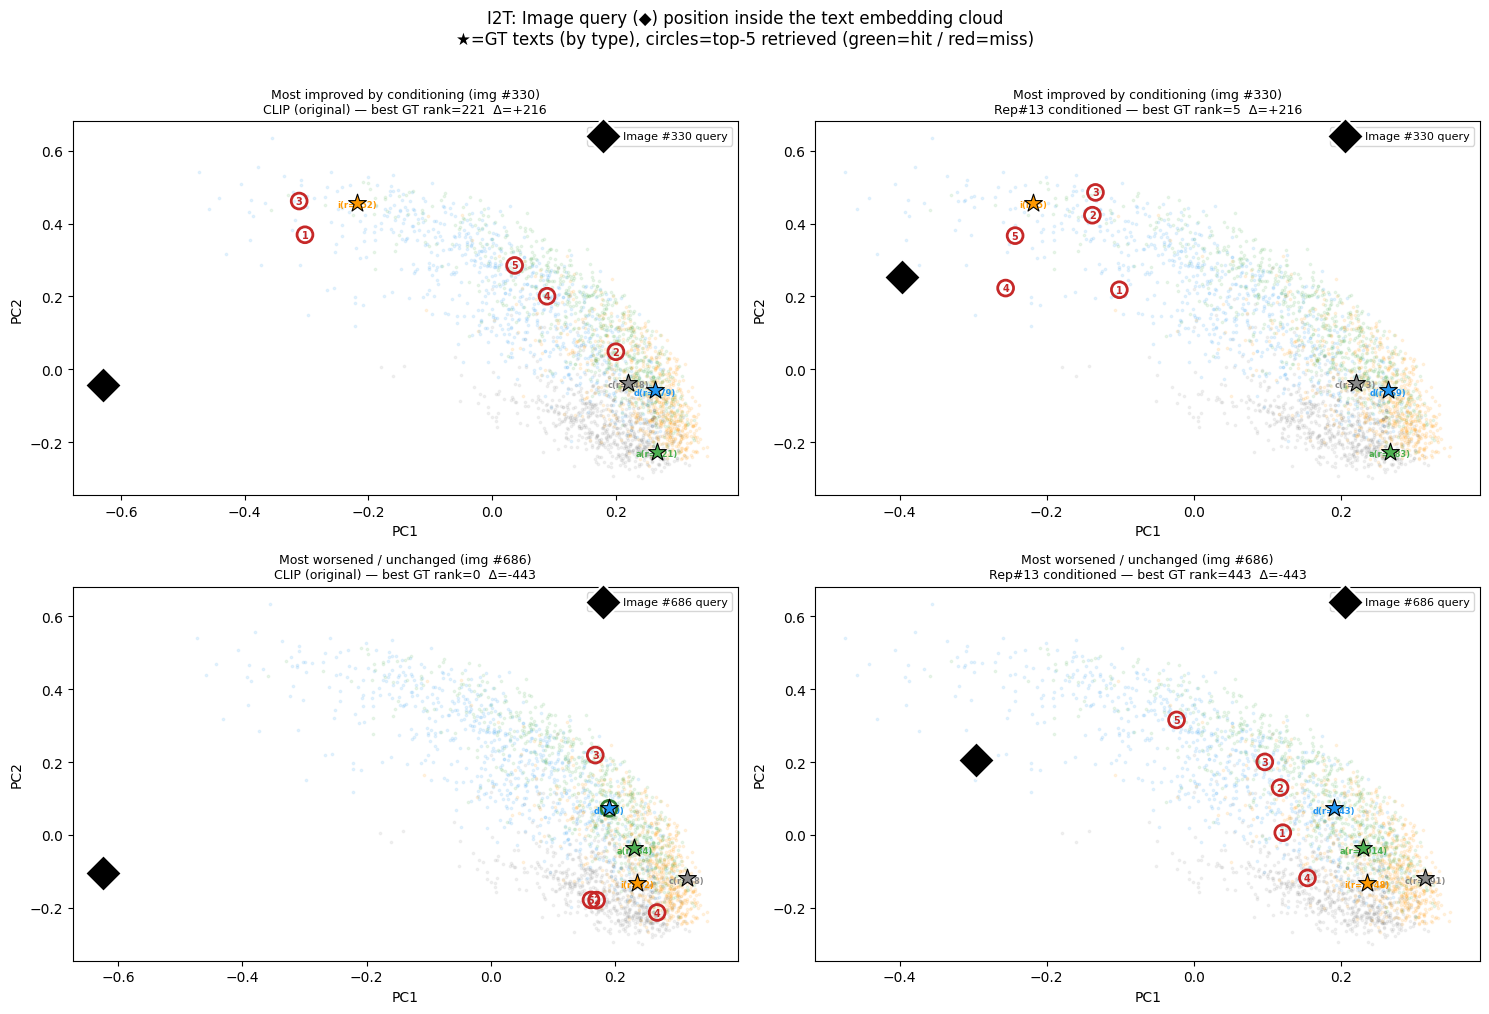

In [30]:
# I2T placement: image query inside text cloud — 2 examples (best improvement, worst)
_i2t_gain = (clip_i2t_gt_rank.float() - per_rep_i2t_gt_rank[_bi2t].float()) if HAS_I2T \
            else torch.zeros(n_img)
_ex_i2t = [int(_i2t_gain.argmax()), int(_i2t_gain.argmin())]
_ex_labels_i2t = ['Most improved by conditioning', 'Most worsened / unchanged']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for row, img_idx in enumerate(_ex_i2t):
    gt_txts = img2txt[img_idx].tolist()
    for col, (lbl, pt, sims_row) in enumerate([
        ('CLIP (original)', _img_pca[img_idx],      _sims_clip_i2t[img_idx]),
        (f'Rep#{_bi2t} conditioned', _cond_i2t_pca[img_idx], _sims_i2t[img_idx]),
    ]):
        ax = axes[row, col]
        # Text cloud background
        for t in range(4):
            m = (test_cap_types == t).numpy()
            ax.scatter(_txt_pca[m,0], _txt_pca[m,1], s=3, alpha=0.10, color=TYPE_COLORS[t], zorder=1)
        # Top-5 retrieved texts
        top5 = sims_row.argsort(descending=True)[:5].tolist()
        for k, tidx in enumerate(top5):
            is_gt = tidx in gt_txts
            ec = '#2e7d32' if is_gt else '#c62828'
            ax.scatter(_txt_pca[tidx,0], _txt_pca[tidx,1], s=130, zorder=4,
                       facecolors='none', edgecolors=ec, linewidths=2)
            ax.text(_txt_pca[tidx,0], _txt_pca[tidx,1], str(k+1),
                    fontsize=7, ha='center', va='center', color=ec, fontweight='bold')
        # GT texts
        gt_rks = []
        for t, gi in enumerate(gt_txts):
            rk = int((sims_row >= sims_row[gi]).sum()) - 1
            gt_rks.append(rk)
            ax.scatter(_txt_pca[gi,0], _txt_pca[gi,1], s=180, marker='*',
                       color=TYPE_COLORS[t], zorder=5, edgecolors='black', linewidths=0.8)
            ax.text(_txt_pca[gi,0], _txt_pca[gi,1] - 0.013, f'{TYPE_NAMES[t][0]}(r={rk})',
                    fontsize=6, ha='center', color=TYPE_COLORS[t], fontweight='bold')
        # Image query position
        ax.scatter(*pt, s=350, marker='D', color='black', zorder=6, edgecolors='white', linewidths=1.5,
                   label=f'Image #{img_idx} query')
        gain = _i2t_gain[img_idx].item()
        ax.set_title(f'{_ex_labels_i2t[row]} (img #{img_idx})\n'
                     f'{lbl} — best GT rank={min(gt_rks)}  Δ={gain:+.0f}', fontsize=9)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=8)

plt.suptitle('I2T: Image query (◆) position inside the text embedding cloud\n'
             '★=GT texts (by type), circles=top-5 retrieved (green=hit / red=miss)', y=1.01)
plt.tight_layout(); plt.show()


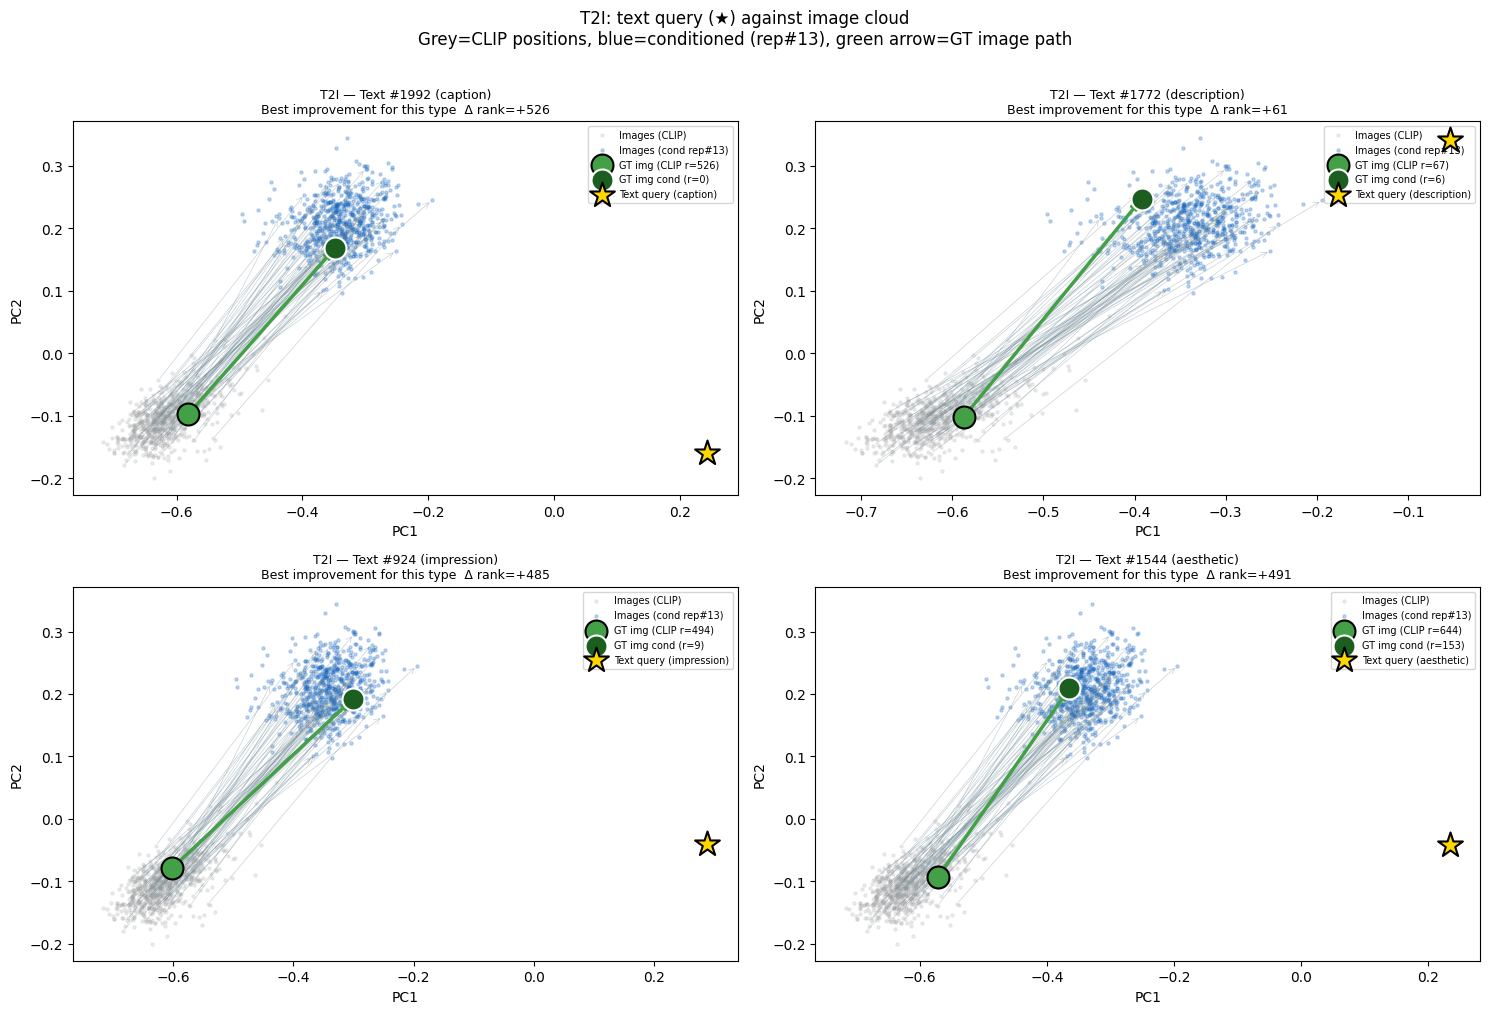

In [31]:
# T2I placement: text query against shifting image cloud — one example per caption type
_t2i_gain = clip_gt_rank.float() - per_rep_gt_rank[_bt2i].float()
_ex_t2i = []
for t in range(4):
    mask = test_cap_types == t
    idx_t = torch.where(mask)[0]
    _ex_t2i.append(int(idx_t[_t2i_gain[mask].argmax()]))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for row in range(2):
    for col in range(2):
        txt_idx = _ex_t2i[row*2 + col]
        ax = axes[row, col]
        gt_img = txt2img[txt_idx].item()
        gain   = _t2i_gain[txt_idx].item()

        # Original image cloud (faded)
        ax.scatter(_img_pca[:,0], _img_pca[:,1], s=5, alpha=0.18, color='#9e9e9e', zorder=1,
                   label='Images (CLIP)')
        # Conditioned image cloud
        ax.scatter(_cond_t2i_pca[:,0], _cond_t2i_pca[:,1], s=5, alpha=0.25, color='#1565c0', zorder=2,
                   label=f'Images (cond rep#{_bt2i})')
        # Arrows: original → conditioned (subsampled)
        step = max(1, n_img // 60)
        for ii in range(0, n_img, step):
            if ii == gt_img: continue
            ax.annotate('', xy=_cond_t2i_pca[ii], xytext=_img_pca[ii],
                        arrowprops=dict(arrowstyle='->', color='#78909c', lw=0.5, alpha=0.4))
        # GT image: original and conditioned with arrow
        ax.scatter(*_img_pca[gt_img], s=250, marker='o', color='#43a047', zorder=6,
                   edgecolors='black', linewidths=1.5, label=f'GT img (CLIP r={clip_gt_rank[txt_idx]})')
        ax.scatter(*_cond_t2i_pca[gt_img], s=250, marker='o', color='#1b5e20', zorder=6,
                   edgecolors='white', linewidths=1.5, label=f'GT img cond (r={per_rep_gt_rank[_bt2i,txt_idx]})')
        ax.annotate('', xy=_cond_t2i_pca[gt_img], xytext=_img_pca[gt_img],
                    arrowprops=dict(arrowstyle='->', color='#43a047', lw=2.5))
        # Text query
        tpt = _pca_j.transform(_txt_np[txt_idx:txt_idx+1])[0]
        ax.scatter(*tpt, s=350, marker='*', color='gold', zorder=7, edgecolors='black',
                   linewidths=1.5, label=f'Text query ({TYPE_NAMES[test_cap_types[txt_idx]]})')
        ax.set_title(f'T2I — Text #{txt_idx} ({TYPE_NAMES[test_cap_types[txt_idx]]})\n'
                     f'Best improvement for this type  Δ rank={gain:+.0f}', fontsize=9)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'T2I: text query (★) against image cloud\n'
             f'Grey=CLIP positions, blue=conditioned (rep#{_bt2i}), green arrow=GT image path', y=1.01)
plt.tight_layout(); plt.show()


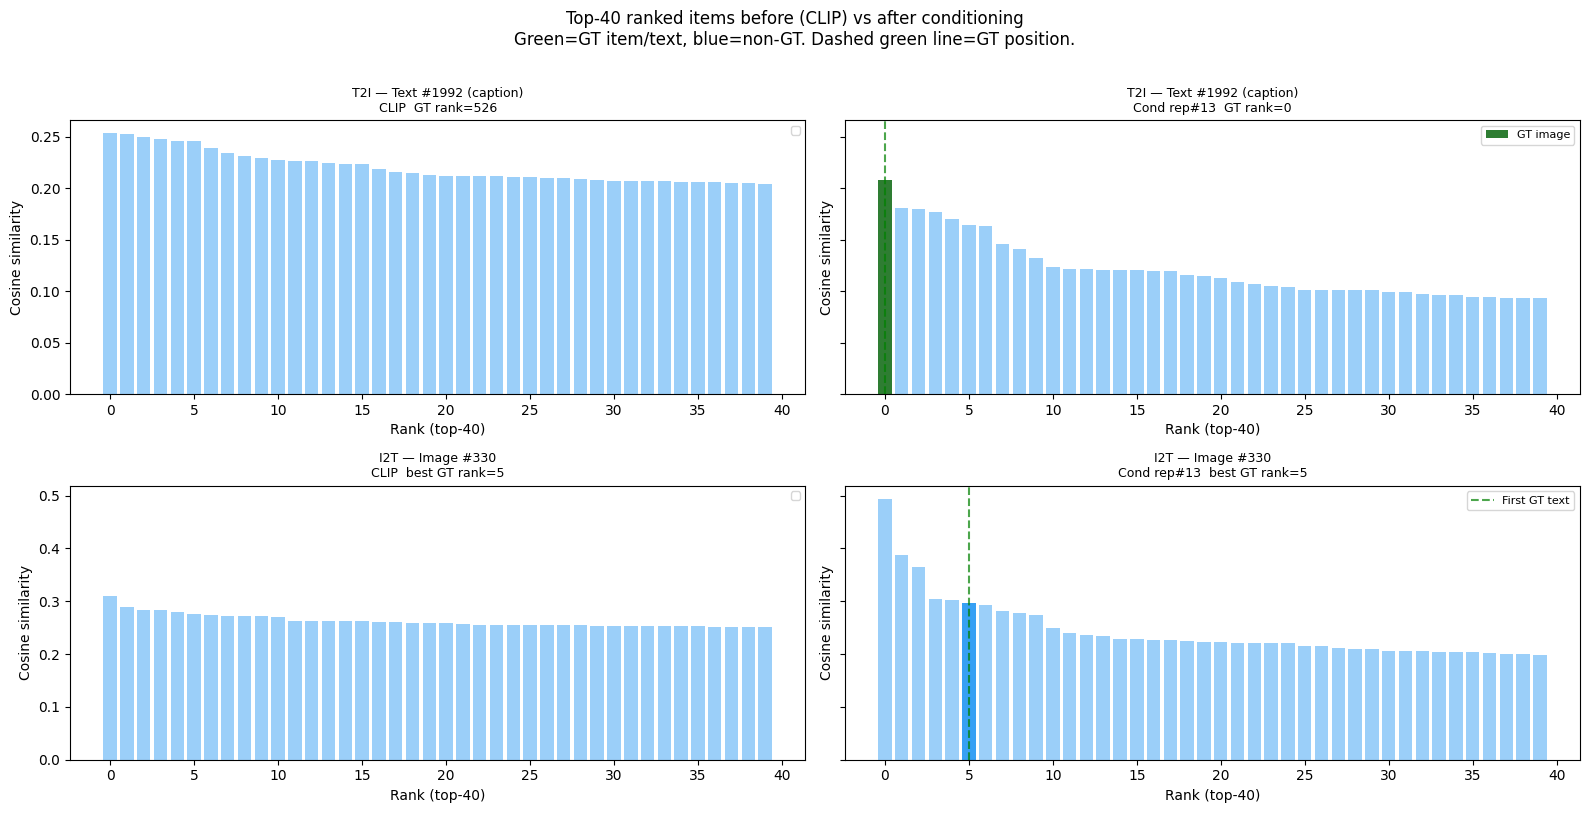

In [32]:
# Similarity bar chart for one example per direction — shows rank inversion concretely
# Pick the text query with largest T2I improvement and the image query with largest I2T improvement
_ex_txt = _ex_t2i[0]  # best T2I improvement for first caption type
_ex_img = _ex_i2t[0]  # best I2T improvement
N_SHOW = 40

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey='row')

# ─ T2I ─
for col, (lbl, sims_row) in enumerate([('CLIP', _sims_clip[_ex_txt]),
                                        (f'Cond rep#{_bt2i}', _sims_t2i[_ex_txt])]):
    ax = axes[0, col]
    sorted_idx = sims_row.argsort(descending=True)[:N_SHOW]
    vals = sims_row[sorted_idx].numpy()
    is_gt_arr = (sorted_idx == txt2img[_ex_txt]).numpy()
    colors = ['#2e7d32' if g else '#90caf9' for g in is_gt_arr]
    ax.bar(range(N_SHOW), vals, color=colors, alpha=0.9)
    gt_pos = int(is_gt_arr.argmax()) if is_gt_arr.any() else -1
    if gt_pos >= 0:
        ax.bar(gt_pos, vals[gt_pos], color='#2e7d32', alpha=1.0, label='GT image')
        ax.axvline(gt_pos, color='green', lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel(f'Rank (top-{N_SHOW})')
    ax.set_ylabel('Cosine similarity')
    ax.set_title(f'T2I — Text #{_ex_txt} ({TYPE_NAMES[test_cap_types[_ex_txt]]})\n'
                 f'{lbl}  GT rank={int((sims_row >= sims_row[txt2img[_ex_txt]]).sum())-1}', fontsize=9)
    ax.legend(fontsize=8)

# ─ I2T ─
for col, (lbl, sims_row) in enumerate([('CLIP', _sims_clip_i2t[_ex_img]),
                                        (f'Cond rep#{_bi2t}', _sims_i2t[_ex_img])]):
    ax = axes[1, col]
    sorted_idx = sims_row.argsort(descending=True)[:N_SHOW]
    vals = sims_row[sorted_idx].numpy()
    gt_set = set(img2txt[_ex_img].tolist())
    is_gt_arr = np.array([idx.item() in gt_set for idx in sorted_idx])
    colors = [TYPE_COLORS[test_cap_types[idx].item()] if idx.item() in gt_set else '#90caf9'
              for idx in sorted_idx]
    ax.bar(range(N_SHOW), vals, color=colors, alpha=0.9)
    # Find position of best GT text
    gt_pos = int(is_gt_arr.argmax()) if is_gt_arr.any() else -1
    if gt_pos >= 0:
        ax.axvline(gt_pos, color='green', lw=1.5, ls='--', alpha=0.7, label='First GT text')
    ax.set_xlabel(f'Rank (top-{N_SHOW})')
    ax.set_ylabel('Cosine similarity')
    ax.set_title(f'I2T — Image #{_ex_img}\n'
                 f'{lbl}  best GT rank={per_rep_i2t_gt_rank[_bi2t,_ex_img].item()}', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle(f'Top-{N_SHOW} ranked items before (CLIP) vs after conditioning\n'
             'Green=GT item/text, blue=non-GT. Dashed green line=GT position.', y=1.01)
plt.tight_layout(); plt.show()


### B — Rank Dynamics: Displaced Distractors & Boosted Non-GTs

For each query, classify every non-GT item into four buckets:

| | **Below GT after** | **Above GT after** |
|---|---|---|
| **Below GT before (CLIP)** | unchanged-below | **new distractor** (bad) |
| **Above GT before (CLIP)** | **displaced** (good) | persistent distractor |

Net rank improvement = `n_displaced − n_new_distractor`.

In [33]:
# ─── T2I rank dynamics ───────────────────────────────────────────────────────
_gt_sim_clip_t2i = _sims_clip[torch.arange(n_txt), txt2img]    # [N_txt] GT sim under CLIP
_gt_sim_cond_t2i = _sims_t2i[torch.arange(n_txt), txt2img]     # [N_txt] GT sim under condition

_above_clip = _sims_clip > _gt_sim_clip_t2i.unsqueeze(1)        # [N_txt, N_img] was above GT
_above_cond = _sims_t2i  > _gt_sim_cond_t2i.unsqueeze(1)        # [N_txt, N_img] now above GT

t2i_displaced   = (_above_clip & ~_above_cond).sum(dim=1).float()  # [N_txt]
t2i_new_dist    = (~_above_clip & _above_cond).sum(dim=1).float()  # [N_txt]
t2i_rank_change = clip_gt_rank.float() - per_rep_gt_rank[_bt2i].float()  # positive=improvement
# Sanity: displaced - new_dist == rank_change
_err = (t2i_displaced - t2i_new_dist - t2i_rank_change).abs().max().item()
if _err > 0: print(f'Note: T2I rank sanity max-error={_err:.0f} (sim-tie artefact, expected <2)')

# ─── I2T rank dynamics ───────────────────────────────────────────────────────
_gt_sim_clip_i2t = _sims_clip_i2t[                               # [N_img] best GT sim under CLIP
    torch.arange(n_img).unsqueeze(1), img2txt].max(dim=1).values
_gt_sim_cond_i2t = _sims_i2t[
    torch.arange(n_img).unsqueeze(1), img2txt].max(dim=1).values  # [N_img]

_above_clip_i2t = _sims_clip_i2t > _gt_sim_clip_i2t.unsqueeze(1)  # [N_img, N_txt]
_above_cond_i2t = _sims_i2t      > _gt_sim_cond_i2t.unsqueeze(1)  # [N_img, N_txt]

i2t_displaced = (_above_clip_i2t & ~_above_cond_i2t).sum(dim=1).float()  # [N_img]
i2t_new_dist  = (~_above_clip_i2t & _above_cond_i2t).sum(dim=1).float()  # [N_img]
i2t_rank_change_full = clip_i2t_gt_rank.float() - per_rep_i2t_gt_rank[_bi2t].float()

# ─── Statistics table ────────────────────────────────────────────────────────
print(f'Condition: T2I=rep#{_bt2i}  I2T=rep#{_bi2t}')
print(f'\n{"":<30} {"T2I":>10} {"I2T":>10}')
print('-'*52)
for lbl, tv, iv in [
    ('Mean displaced (good)',   t2i_displaced.mean(),   i2t_displaced.mean()),
    ('Mean new distractors (bad)', t2i_new_dist.mean(), i2t_new_dist.mean()),
    ('Mean net rank change',    t2i_rank_change.mean(), i2t_rank_change_full.mean()),
    ('Queries with net gain',   (t2i_rank_change>0).float().mean()*100, (i2t_rank_change_full>0).float().mean()*100),
    ('Queries with net loss',   (t2i_rank_change<0).float().mean()*100, (i2t_rank_change_full<0).float().mean()*100),
    ('Queries with new distractors > 0', (t2i_new_dist>0).float().mean()*100, (i2t_new_dist>0).float().mean()*100),
]:
    print(f'{lbl:<30} {tv.item():>10.2f} {iv.item():>10.2f}')

# ─── Per-type breakdown ─────────────────────────────────────────────────────
print('\nT2I: mean new distractors per caption type:')
for t in range(4):
    mask = test_cap_types == t
    print(f'  {TYPE_NAMES[t]:>13}: displaced={t2i_displaced[mask].mean():.2f}  '
          f'new_dist={t2i_new_dist[mask].mean():.2f}  net={t2i_rank_change[mask].mean():.2f}')


Note: T2I rank sanity max-error=1 (sim-tie artefact, expected <2)
Condition: T2I=rep#13  I2T=rep#13

                                      T2I        I2T
----------------------------------------------------
Mean displaced (good)               10.58       1.92
Mean new distractors (bad)          11.07       8.64
Mean net rank change                -0.49      -6.73
Queries with net gain               31.66      14.45
Queries with net loss               27.23      36.69
Queries with new distractors > 0      39.59      42.07

T2I: mean new distractors per caption type:
        caption: displaced=16.62  new_dist=11.79  net=4.84
    description: displaced=1.11  new_dist=2.23  net=-1.11
     impression: displaced=12.74  new_dist=14.07  net=-1.32
      aesthetic: displaced=11.83  new_dist=16.20  net=-4.37


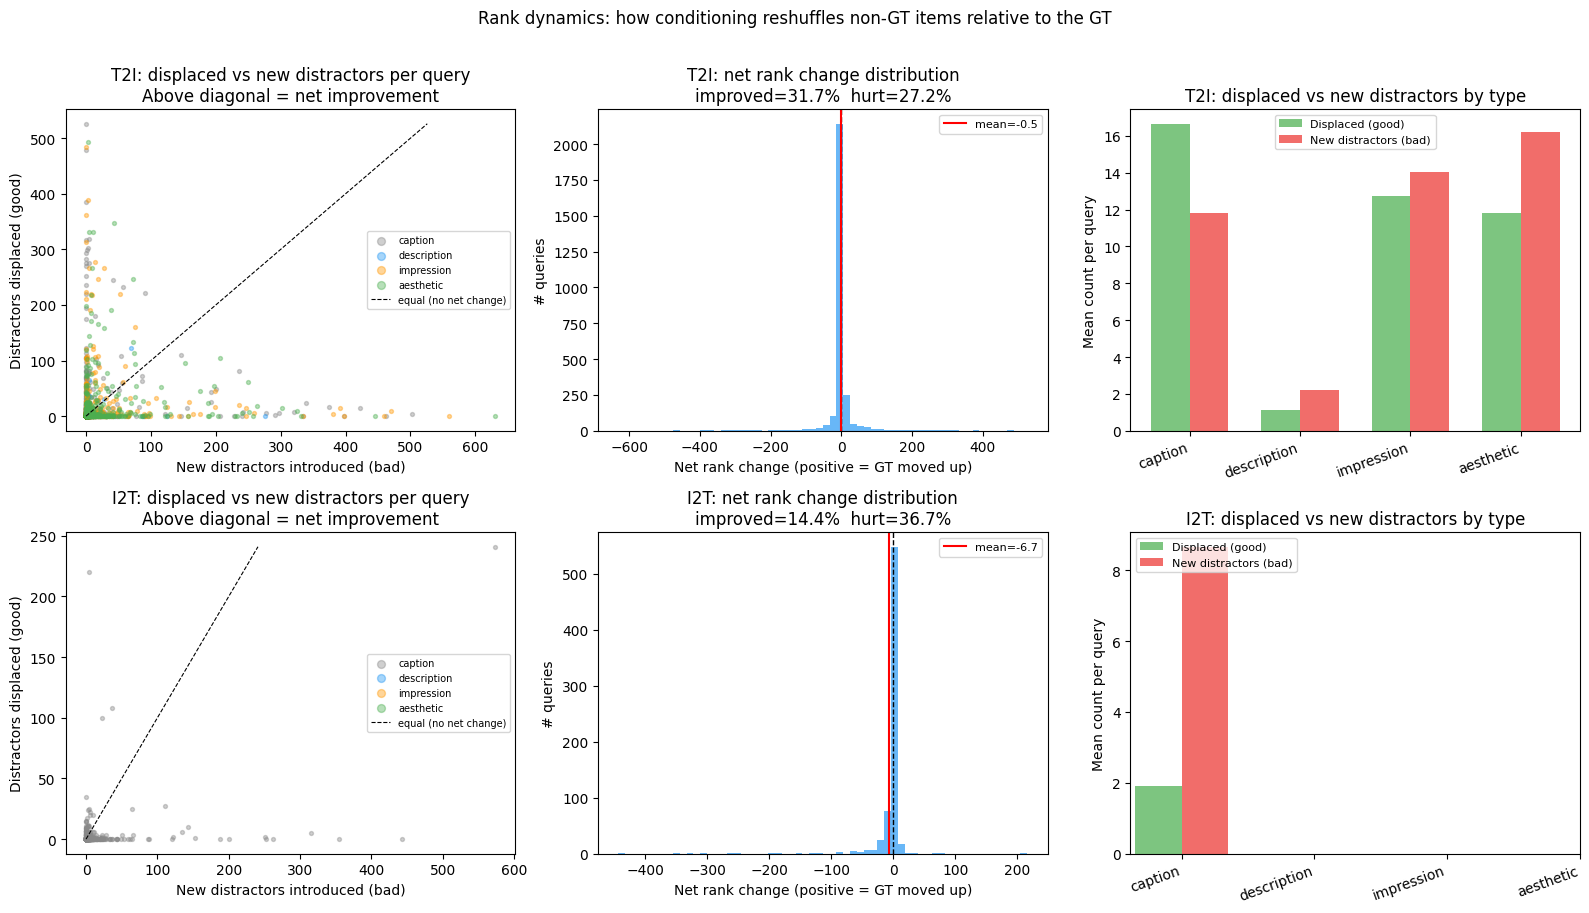

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (direction, displaced, new_dist, rank_chg, types_vec) in enumerate([
    ('T2I', t2i_displaced, t2i_new_dist, t2i_rank_change,      test_cap_types),
    ('I2T', i2t_displaced, i2t_new_dist, i2t_rank_change_full,
     torch.zeros(n_img, dtype=torch.long)),  # images have all 4 types; no per-type split
]):
    # ── scatter: displaced vs new distractors (one dot per query) ─────────
    ax = axes[row, 0]
    for t in range(4):
        m = types_vec == t
        ax.scatter(new_dist[m].numpy(), displaced[m].numpy(),
                   s=8, alpha=0.4, color=TYPE_COLORS[t], label=TYPE_NAMES[t])
    ax.plot([0, displaced.max()], [0, displaced.max()], 'k--', lw=0.8, label='equal (no net change)')
    ax.set_xlabel('New distractors introduced (bad)')
    ax.set_ylabel('Distractors displaced (good)')
    ax.set_title(f'{direction}: displaced vs new distractors per query\n'
                 f'Above diagonal = net improvement')
    ax.legend(fontsize=7, markerscale=2)

    # ── histogram: net rank change ─────────────────────────────────────────
    ax = axes[row, 1]
    ax.hist(rank_chg.numpy(), bins=60, color='#42a5f5', alpha=0.8)
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.axvline(rank_chg.mean().item(), color='red', lw=1.5,
               label=f'mean={rank_chg.mean():.1f}')
    improved = (rank_chg > 0).float().mean().item() * 100
    hurt     = (rank_chg < 0).float().mean().item() * 100
    ax.set_xlabel('Net rank change (positive = GT moved up)')
    ax.set_ylabel('# queries')
    ax.set_title(f'{direction}: net rank change distribution\n'
                 f'improved={improved:.1f}%  hurt={hurt:.1f}%')
    ax.legend(fontsize=8)

    # ── per-type bar: mean new distractors vs displaced ───────────────────
    ax = axes[row, 2]
    x = np.arange(4); w = 0.35
    mean_disp = [displaced[types_vec==t].mean().item() for t in range(4)]
    mean_new  = [new_dist[types_vec==t].mean().item()  for t in range(4)]
    ax.bar(x - w/2, mean_disp, w, label='Displaced (good)', color='#66bb6a', alpha=0.85)
    ax.bar(x + w/2, mean_new,  w, label='New distractors (bad)', color='#ef5350', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(TYPE_NAMES, rotation=20, ha='right')
    ax.set_ylabel('Mean count per query')
    ax.set_title(f'{direction}: displaced vs new distractors by type')
    ax.legend(fontsize=8)

plt.suptitle('Rank dynamics: how conditioning reshuffles non-GT items relative to the GT', y=1.01)
plt.tight_layout(); plt.show()


### C — Mean Cosine Similarity Before vs After Conditioning

Three quantities compared for CLIP and best-rep condition:

- **`mean_all`**: mean sim over all (query, gallery) pairs — measures overall affinity shift
- **`mean_gt`**: mean sim for GT pairs only — does the GT pair get closer?
- **`mean_ngt`**: mean sim for non-GT pairs — do distractors also get closer?
- **`selectivity`** = `mean_gt − mean_ngt` — does the GT separate from the crowd?

High selectivity lift → conditioning sharpens the signal; if both GT and non-GT improve equally → overall gallery shift with no signal sharpening.

                       mean_all    mean_gt   mean_ngt  selectivity
-----------------------------------------------------------------
T2I CLIP                0.15151    0.27864    0.15133      0.12731
T2I rep#13              0.00940    0.27296    0.00902      0.26394
I2T CLIP                0.15151    0.27864    0.15133      0.12731
I2T rep#13              0.00940    0.27296    0.00902      0.26394

T2I selectivity per caption type (CLIP → conditioned):
        caption: sel CLIP=+0.10431  sel cond=+0.27853  Δsel=+0.17422
    description: sel CLIP=+0.18273  sel cond=+0.36384  Δsel=+0.18110
     impression: sel CLIP=+0.10362  sel cond=+0.20103  Δsel=+0.09741
      aesthetic: sel CLIP=+0.11860  sel cond=+0.21237  Δsel=+0.09377


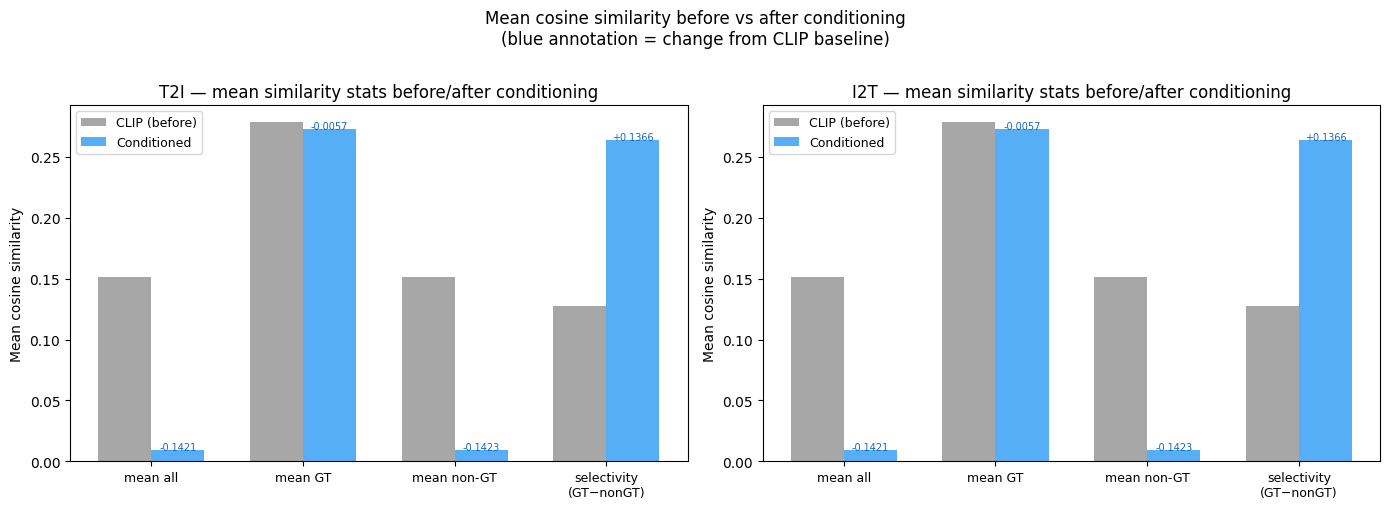


T2I selectivity for all K representatives:
  Rep #13: sel=+0.26394  mean_gt=0.27296  mean_ngt=0.00902
  Rep # 6: sel=+0.25121  mean_gt=0.26759  mean_ngt=0.01639
  Rep #28: sel=+0.25799  mean_gt=0.25274  mean_ngt=-0.00525
  Rep #14: sel=+0.23565  mean_gt=0.28150  mean_ngt=0.04585
  Rep #22: sel=+0.23313  mean_gt=0.28167  mean_ngt=0.04854
  Rep # 2: sel=+0.20509  mean_gt=0.25886  mean_ngt=0.05378
  Rep #19: sel=+0.24289  mean_gt=0.20884  mean_ngt=-0.03405
  Rep #12: sel=+0.21343  mean_gt=0.24519  mean_ngt=0.03176
  Rep # 3: sel=+0.22301  mean_gt=0.28565  mean_ngt=0.06264
  Rep # 0: sel=+0.23774  mean_gt=0.28817  mean_ngt=0.05043


In [35]:
def _sim_stats(sims_q_g, gt_map):
    """
    sims_q_g : [N_q, N_g] sim matrix
    gt_map   : [N_q] index of GT item for each query  (use txt2img for T2I)
               OR [N_q, cpi] for multiple GTs (use img2txt for I2T)
    Returns dict: mean_all, mean_gt, mean_ngt, selectivity
    """
    N_q, N_g = sims_q_g.shape
    mean_all = sims_q_g.mean().item()
    if gt_map.dim() == 1:
        gt_sims = sims_q_g[torch.arange(N_q), gt_map]                   # [N_q]
        total_gt_sum = gt_sims.sum().item()
        n_gt_pairs   = N_q
    else:  # [N_q, cpi]
        gt_sims = sims_q_g[torch.arange(N_q).unsqueeze(1), gt_map]      # [N_q, cpi]
        total_gt_sum = gt_sims.sum().item()
        n_gt_pairs   = N_q * gt_map.shape[1]
    mean_gt  = total_gt_sum / n_gt_pairs
    n_ngt    = N_q * N_g - n_gt_pairs
    mean_ngt = (sims_q_g.sum().item() - total_gt_sum) / n_ngt
    return {'mean_all': mean_all, 'mean_gt': mean_gt,
            'mean_ngt': mean_ngt, 'selectivity': mean_gt - mean_ngt}

stats = {
    'T2I CLIP':         _sim_stats(_sims_clip,       txt2img),
    f'T2I rep#{_bt2i}': _sim_stats(_sims_t2i,        txt2img),
    'I2T CLIP':         _sim_stats(_sims_clip_i2t,   img2txt),
    f'I2T rep#{_bi2t}': _sim_stats(_sims_i2t,        img2txt),
}

print(f'{"":<20} {"mean_all":>10} {"mean_gt":>10} {"mean_ngt":>10} {"selectivity":>12}')
print('-'*65)
for name, s in stats.items():
    print(f'{name:<20} {s["mean_all"]:>10.5f} {s["mean_gt"]:>10.5f} '
          f'{s["mean_ngt"]:>10.5f} {s["selectivity"]:>12.5f}')

# Per-type T2I selectivity
print('\nT2I selectivity per caption type (CLIP → conditioned):')
for t in range(4):
    mask = test_cap_types == t
    idx_t = torch.where(mask)[0]
    s_c = _sim_stats(_sims_clip[idx_t], txt2img[idx_t] )
    s_k = _sim_stats(_sims_t2i [idx_t], txt2img[idx_t] )
    print(f'  {TYPE_NAMES[t]:>13}: sel CLIP={s_c["selectivity"]:+.5f}  '
          f'sel cond={s_k["selectivity"]:+.5f}  '
          f'Δsel={s_k["selectivity"]-s_c["selectivity"]:+.5f}')

# ── Visualisation: grouped bar chart ────────────────────────────────────────
keys   = ['mean_all', 'mean_gt', 'mean_ngt', 'selectivity']
labels = ['mean all', 'mean GT', 'mean non-GT', 'selectivity\n(GT−nonGT)']
pairs  = [('T2I CLIP', f'T2I rep#{_bt2i}'), ('I2T CLIP', f'I2T rep#{_bi2t}')]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (base, cond) in zip(axes, pairs):
    x = np.arange(len(keys)); w = 0.35
    bvals = [stats[base][k] for k in keys]
    cvals = [stats[cond][k] for k in keys]
    ax.bar(x - w/2, bvals, w, label='CLIP (before)', color='#9e9e9e', alpha=0.9)
    ax.bar(x + w/2, cvals, w, label='Conditioned', color='#42a5f5', alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Mean cosine similarity')
    ax.set_title(f'{base[:3]} — mean similarity stats before/after conditioning')
    ax.legend(fontsize=9)
    # Annotate deltas
    for xi, (bv, cv) in enumerate(zip(bvals, cvals)):
        ax.text(xi + w/2, cv + 0.0002, f'{cv-bv:+.4f}', fontsize=7, ha='center', color='#1565c0')
plt.suptitle('Mean cosine similarity before vs after conditioning\n'
             '(blue annotation = change from CLIP baseline)', y=1.01)
plt.tight_layout(); plt.show()

# ── Selectivity over all K conditions (not just best rep) ───────────────────
if HAS_CA:
    print('\nT2I selectivity for all K representatives:')
    for ri in sort_order[:10]:  # top-10 by T2I performance
        with torch.no_grad():
            _ce = apply_condition(all_img_emb, representatives[ri:ri+1])
        _sm = txt_n @ _ce.T
        s = _sim_stats(_sm, txt2img)
        print(f'  Rep #{ri:2d}: sel={s["selectivity"]:+.5f}  '
              f'mean_gt={s["mean_gt"]:.5f}  mean_ngt={s["mean_ngt"]:.5f}')
